## 1. Objective and predeclared evaluation rules

This study asks whether supervised machine learning or alternative reinforcement-learning algorithms improve on the earlier G-learning experiment. **Accuracy means predicting whether the next open-to-open return is positive.** Trading performance is a separate objective: profitable decisions depend on return magnitudes, exposure and costs, not just direction.

We use the same 2,335-row historical STOCKS_GOOGL snapshot with actual dates. The first 252 observations are for calibration/history; training ends at 60% of source rows, validation spans 60–80%, and test spans 80–100%. Validation is itself divided into a tuning block and a selection block. Model hyperparameters use four expanding training-only folds with a one-row gap. Probability/decision thresholds and trading rules use the first validation block; final model/strategy selection uses the second. **All selected choices are frozen before test evaluation.** No random train/test split is used.

Primary classification ranking: balanced accuracy, with Brier loss as tie-breaker. Ordinary accuracy, precision, recall, F1, ROC-AUC, average precision and log loss are also reported. 
**Research limitation:** earlier notebooks already explored and evaluated this final segment. It is computationally excluded from fitting and current selection, but it is not genuinely unseen research data.

In [1]:
import json, hashlib, time, warnings, platform
from pathlib import Path
from dataclasses import dataclass, asdict
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy.special import logsumexp
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, brier_score_loss, log_loss, confusion_matrix, roc_curve, precision_recall_curve, mean_absolute_error, mean_squared_error, r2_score
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from threadpoolctl import threadpool_limits
from gym_anytrading.datasets import STOCKS_GOOGL
# Limit native-library threads for predictable performance on a small dataset.
THREAD_LIMIT=threadpool_limits(limits=1)
OUT=Path('ml_rl_outputs'); OUT.mkdir(exist_ok=True)
SEEDS=[7,19,43]; RL_BUDGET=24_000; FEE=.001; GAMMA=.99
plt.rcParams.update({'figure.figsize':(12,5),'figure.dpi':110,'axes.grid':True,'grid.alpha':.2})
pd.set_option('display.max_columns',20); pd.set_option('display.float_format',lambda x:f'{x:,.5f}')
def explain(s): display(Markdown('**Output interpretation:** '+s))
FIGURE_NUMBER=0
def show():
 global FIGURE_NUMBER
 FIGURE_NUMBER+=1; plt.tight_layout(); plt.savefig(OUT/f'figure_{FIGURE_NUMBER:02d}.png',bbox_inches='tight'); plt.show(); plt.close('all')
versions={p:metadata.version(p) for p in ['numpy','pandas','scipy','scikit-learn','matplotlib','gym-anytrading']}
display(pd.Series(versions,name='version').to_frame())

,version
numpy,2.4.6
pandas,3.0.5
scipy,1.17.1
scikit-learn,1.9.0
matplotlib,3.11.1
gym-anytrading,2.0.0


## 2. Verify dataset identity and translate EDA into hypotheses

The previous EDA found very high correlations among OHLC levels, a relative-volume/absolute-return Spearman correlation around 0.397, weak training forward-return associations (largest absolute value around 0.025), and changing feature distributions over time. Therefore we avoid raw price levels as predictors, use relative indicators and lagged returns, include volatility/volume context, compare simple and flexible models, and evaluate stability chronologically.

In [2]:
df=STOCKS_GOOGL.copy().sort_index()
DATA_HASH=hashlib.sha256(df.to_csv().encode()).hexdigest()
assert len(df)==2335 and np.isclose(df.Close.iloc[0],196.946945,atol=1e-5)
assert DATA_HASH=='050162e746a59f0c6e0a144978afb4adddb65d8b72dd331c774210cbdec38a5b'
assert isinstance(df.index,pd.DatetimeIndex) and df.index.is_unique and df.index.is_monotonic_increasing
assert np.isfinite(df.to_numpy()).all() and (df[['Open','High','Low','Close']]>0).all().all()
assert np.allclose(df.Close,df['Adj Close'])
N=len(df); CAL=252; TRAIN_END=int(.6*N); VAL_END=int(.8*N); VAL_MID=(TRAIN_END+VAL_END)//2
BOUNDS={'train':(CAL,TRAIN_END),'validation_tune':(TRAIN_END,VAL_MID),'validation_select':(VAL_MID,VAL_END),'test':(VAL_END,N)}
OPEN=df.Open.to_numpy(dtype=float)
display(df.head()); print('Dataset SHA256:',DATA_HASH)
explain(f'Confirmed {N:,} rows dated {df.index[0].date()} to {df.index[-1].date()}. No replacement market download or artificial business dates are used. Close and Adj Close match in this snapshot; corporate-action conventions remain a vendor-data limitation.')

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2009-05-22,198.52853,199.52452,196.19620,196.94694,196.94694,3433700
2009-05-26,196.17117,202.70270,195.19519,202.38238,202.38238,6202700
2009-05-27,203.02303,206.13614,202.60761,202.98299,202.98299,6062500
2009-05-28,204.54454,206.01602,202.50751,205.40541,205.40541,5332200
2009-05-29,206.26126,208.82382,205.55556,208.82382,208.82382,5291100


Dataset SHA256: 050162e746a59f0c6e0a144978afb4adddb65d8b72dd331c774210cbdec38a5b


**Output interpretation:** Confirmed 2,335 rows dated 2009-05-22 to 2018-08-29. No replacement market download or artificial business dates are used. Close and Adj Close match in this snapshot; corporate-action conventions remain a vendor-data limitation.

## 3. Feature engineering and precise target alignment

In [3]:
def build_features(frame):
 p=frame.Close; r=p.pct_change(fill_method=None); f=pd.DataFrame(index=frame.index)
 for lag in [0,1,2,4]: f[f'return_lag{lag+1}']=r.shift(lag)
 for window in [5,10,20]: f[f'momentum{window}']=p.pct_change(window,fill_method=None)
 sma20=p.rolling(20).mean(); sma50=p.rolling(50).mean()
 f['trend_gap']=sma20/sma50-1; f['price_sma20']=p/sma20-1
 f['macd_pct']=(p.ewm(span=12,adjust=False,min_periods=12).mean()-p.ewm(span=26,adjust=False,min_periods=26).mean())/p
 delta=p.diff(); gain=delta.clip(lower=0).ewm(alpha=1/14,adjust=False,min_periods=14).mean(); loss=(-delta.clip(upper=0)).ewm(alpha=1/14,adjust=False,min_periods=14).mean()
 f['rsi']=100-100/(1+gain/loss); f.loc[(gain==0)&(loss==0),'rsi']=50
 f['volatility5']=r.rolling(5).std(); f['volatility20']=r.rolling(20).std()
 f['vol_ratio']=f.volatility5/f.volatility20
 f['bb_width']=4*p.rolling(20).std(ddof=0)/sma20
 f['range_pct']=(frame.High-frame.Low)/p
 f['intraday']=p/frame.Open-1; f['overnight']=frame.Open/p.shift(1)-1
 f['relative_volume']=frame.Volume/frame.Volume.shift(1).rolling(20).mean()
 f['log_volume_change']=np.log(frame.Volume).diff()
 f['signed_volume']=np.sign(r)*f.relative_volume
 # Every feature shifts one session: at open t we know only through close t-1.
 return f.shift(1).replace([np.inf,-np.inf],np.nan)
X=build_features(df)
FORWARD=pd.Series(np.r_[OPEN[1:]/OPEN[:-1]-1,np.nan],index=df.index,name='next_open_return')
y=(FORWARD>0).astype(int); y.iloc[-1]=-1  # Sentinel: the final undefined target is never fitted.
COMPACT=['return_lag1','momentum5','trend_gap','rsi','volatility20','range_pct','relative_volume']
ALL=list(X.columns)
assert X.iloc[CAL:-1].notna().all().all()
def indices(bounds):
 a,b=bounds
 return np.arange(a,b-1)  # Last label ends at the last open INSIDE this block.
IDX={k:indices(v) for k,v in BOUNDS.items()}
training=IDX['train']; tune=IDX['validation_tune']; select=IDX['validation_select']; testing=IDX['test']
display(pd.concat([X.iloc[CAL:CAL+4],FORWARD.iloc[CAL:CAL+4],y.iloc[CAL:CAL+4].rename('up_label')],axis=1))
explain(f'We engineered {len(ALL)} predictors. A feature row at open t predicts the following open, and no target crosses a named split boundary. Cash/long RL decisions later use exactly the same execution interval.')

,return_lag1,return_lag2,return_lag3,return_lag5,momentum5,momentum10,momentum20,trend_gap,price_sma20,macd_pct,...,vol_ratio,bb_width,range_pct,intraday,overnight,relative_volume,log_volume_change,signed_volume,next_open_return,up_label
Date,,,,,,,,,,,,,,,,,,,,,
2010-05-24,-0.00623,-0.03928,-0.00791,0.00087,-0.06991,-0.04277,-0.13384,-0.06096,-0.07336,-0.03575,...,0.72842,0.13583,0.04364,0.00637,-0.01253,2.60048,0.67924,-2.60048,-0.02617,0
2010-05-25,0.01083,-0.00623,-0.03928,-0.01890,-0.06065,-0.08529,-0.10248,-0.06244,-0.05830,-0.03636,...,0.86105,0.14104,0.02722,-0.00743,0.01839,1.05820,-0.80201,1.05820,0.02973,1
2010-05-26,-0.00019,0.01083,-0.00623,-0.00791,-0.04274,-0.06282,-0.09827,-0.06427,-0.05362,-0.03675,...,0.87025,0.14444,0.02817,0.01905,-0.01888,0.73497,-0.36478,-0.73497,0.00597,1
2010-05-27,-0.00335,-0.00019,0.01083,-0.03928,-0.03835,-0.05920,-0.10151,-0.06615,-0.05174,-0.03702,...,0.87849,0.14571,0.03104,-0.01369,0.01048,0.85519,0.14138,-0.85519,0.01606,1


**Output interpretation:** We engineered 21 predictors. A feature row at open t predicts the following open, and no target crosses a named split boundary. Cash/long RL decisions later use exactly the same execution interval.

## 4. Split audit, class balance and leakage tests

In [4]:
split_table=pd.DataFrame([{'split':name,'feature_first_open':df.index[v[0]],'last_execution_open':df.index[v[-1]],'last_target_open':df.index[v[-1]+1],'examples':len(v),'up_fraction':y.iloc[v].mean() if name!='test' else np.nan} for name,v in IDX.items()])
display(split_table)
for name,v in IDX.items(): assert v.max()+1<BOUNDS[name][1]
changed=df.copy(); changed.iloc[TRAIN_END:,changed.columns.get_indexer(['Open','High','Low','Close'])]*=2
pd.testing.assert_frame_equal(build_features(changed).iloc[:TRAIN_END+1],X.iloc[:TRAIN_END+1])
assert np.allclose(FORWARD.iloc[training],OPEN[training+1]/OPEN[training]-1)
CV=list(TimeSeriesSplit(n_splits=4,gap=1).split(training))
folds=[]
for fold,(a,b) in enumerate(CV,1):
 tr,va=training[a],training[b]
 assert tr.max()+1<va.min()
 folds.append({'fold':fold,'train_examples':len(tr),'valid_examples':len(va),'train_target_end':df.index[tr[-1]+1],'validation_feature_open':df.index[va[0]]})
display(pd.DataFrame(folds)); print('PASS: target boundaries, causal feature perturbation, and four purged chronological folds.')
explain(f'Training up-day share is {y.iloc[training].mean():.1%}. An always-up classifier can achieve that ordinary accuracy without using features, while balanced accuracy is 50% when both classes occur. Higher ordinary accuracy alone is therefore insufficient.')

,split,feature_first_open,last_execution_open,last_target_open,examples,up_fraction
0,train,2010-05-24,2014-12-11,2014-12-12,1148,0.52178
1,validation_tune,2014-12-15,2015-11-13,2015-11-16,232,0.51293
2,validation_select,2015-11-17,2016-10-19,2016-10-20,233,0.54077
3,test,2016-10-21,2018-08-28,2018-08-29,466,NaN


,fold,train_examples,valid_examples,train_target_end,validation_feature_open
0,1,231,229,2011-04-21,2011-04-25
1,2,460,229,2012-03-20,2012-03-21
2,3,689,229,2013-02-19,2013-02-20
3,4,918,229,2014-01-15,2014-01-16


PASS: target boundaries, causal feature perturbation, and four purged chronological folds.


**Output interpretation:** Training up-day share is 52.2%. An always-up classifier can achieve that ordinary accuracy without using features, while balanced accuracy is 50% when both classes occur. Higher ordinary accuracy alone is therefore insufficient.

## 5. Training-only associations, redundancy and feature selection plan

,signed_return_spearman,absolute_return_spearman
bb_width,0.06614,0.04178
return_lag5,-0.06059,-0.04905
return_lag1,0.05700,-0.02808
overnight,0.05133,-0.00397
return_lag3,-0.04399,-0.00216
signed_volume,0.03557,-0.02190
macd_pct,-0.03260,-0.14004
intraday,0.03056,-0.01794
trend_gap,-0.02642,-0.10563
log_volume_change,-0.02253,0.04495


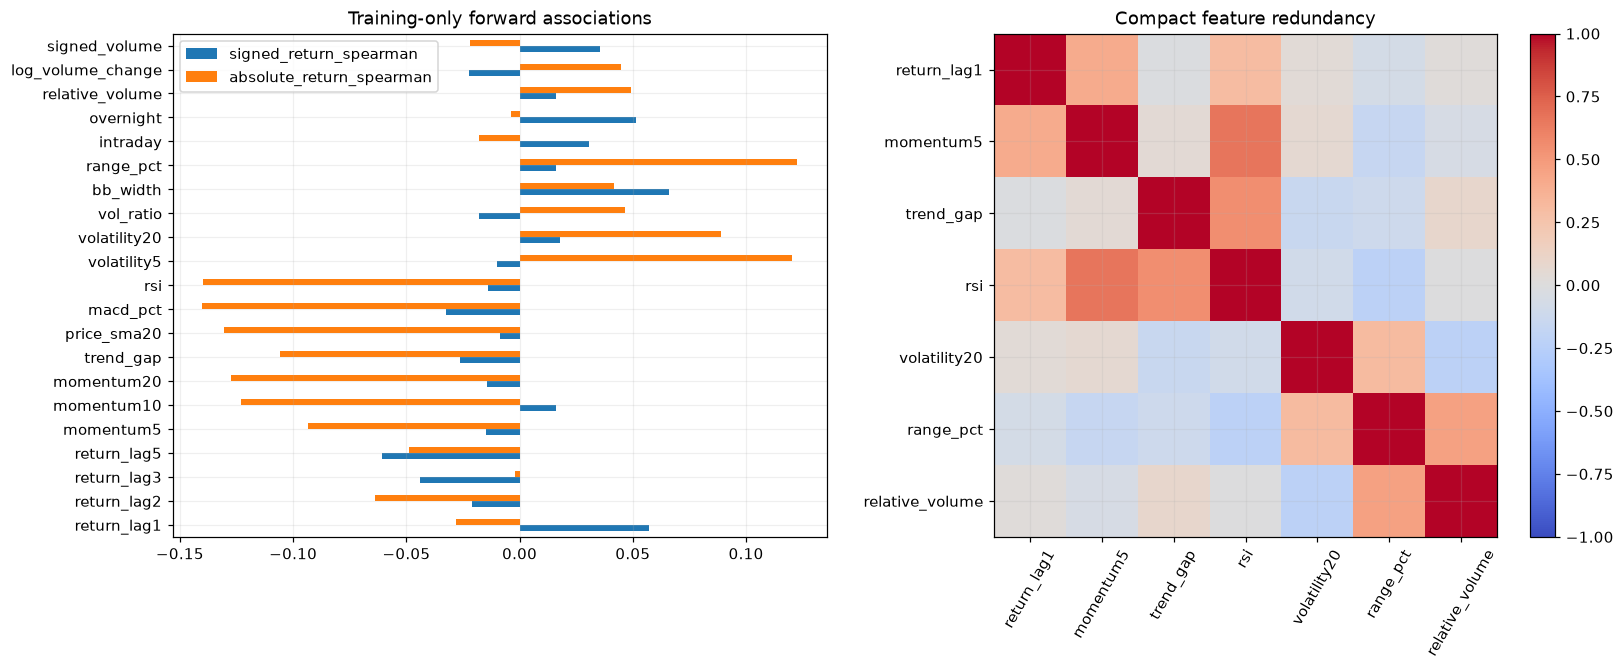

**Output interpretation:** The largest absolute training correlation with the executable signed-return target is 0.066. Correlation screening cannot discover every nonlinear effect; comparing linear and nonlinear models tests whether more flexible patterns survive chronological validation.

In [5]:
associations=pd.DataFrame({'signed_return_spearman':X.iloc[training].corrwith(FORWARD.iloc[training],method='spearman'),'absolute_return_spearman':X.iloc[training].corrwith(FORWARD.iloc[training].abs(),method='spearman')})
display(associations.sort_values('signed_return_spearman',key=abs,ascending=False))
fig,ax=plt.subplots(1,2,figsize=(15,6))
associations.plot.barh(ax=ax[0],title='Training-only forward associations')
c=X.iloc[training][COMPACT].corr(method='spearman'); im=ax[1].imshow(c,vmin=-1,vmax=1,cmap='coolwarm'); ax[1].set(xticks=range(len(c)),yticks=range(len(c)),xticklabels=c.columns,yticklabels=c.columns,title='Compact feature redundancy'); ax[1].tick_params(axis='x',rotation=60); fig.colorbar(im,ax=ax[1]); show()
explain(f'The largest absolute training correlation with the executable signed-return target is {associations.signed_return_spearman.abs().max():.3f}. Correlation screening cannot discover every nonlinear effect; comparing linear and nonlinear models tests whether more flexible patterns survive chronological validation.')

## 6. Metric definitions and a consistent trading simulator

In [6]:
def classification_metrics(target,p,threshold=.5):
 p=np.clip(np.asarray(p,dtype=float),1e-8,1-1e-8); pred=(p>=threshold).astype(int)
 return {'accuracy':accuracy_score(target,pred),'balanced_accuracy':balanced_accuracy_score(target,pred),'precision_up':precision_score(target,pred,zero_division=0),'recall_up':recall_score(target,pred,zero_division=0),'f1_up':f1_score(target,pred,zero_division=0),'roc_auc':roc_auc_score(target,p) if len(np.unique(target))==2 else np.nan,'average_precision':average_precision_score(target,p),'brier_loss':brier_score_loss(target,p),'log_loss':log_loss(target,p,labels=[0,1]),'predicted_up_share':pred.mean()}

def trade_step(t,position,target,fee=FEE,terminal=False,prices=None):
 prices=OPEN if prices is None else prices
 turnover=abs(target-position)+int(terminal)*target
 multiplier=(1-fee*abs(target-position))*(1+target*(prices[t+1]/prices[t]-1))*(1-fee*target if terminal else 1)
 return float(np.log(multiplier)),0 if terminal else target,turnover

def path_from_actions(idx,actions,fee=FEE):
 pos=0; rows=[]
 for j,(t,a) in enumerate(zip(idx,actions)):
  lr,pos,turn=trade_step(t,pos,int(a),fee,j==len(idx)-1)
  rows.append({'date':df.index[t+1],'log_return':lr,'action':int(a),'turnover':turn})
 path=pd.DataFrame(rows).set_index('date'); path['return']=np.expm1(path.log_return); path['equity']=np.exp(path.log_return.cumsum())
 path['drawdown']=path.equity/np.maximum.accumulate(np.r_[1.,path.equity.to_numpy()])[1:]-1
 return path

def trading_metrics(path):
 r=path['return']; std=r.std(); growth=path.log_return.sum()
 return {'net_return':np.expm1(growth),'log_growth':growth,'max_drawdown':path.drawdown.min(),'annualized_vol':std*np.sqrt(252),'sharpe_zero_rf':r.mean()/std*np.sqrt(252) if std>1e-12 else np.nan,'exposure':path.action.mean(),'turnover':path.turnover.sum(),'score':growth-.5*abs(path.drawdown.min())}
# Independent endpoint checks catch fee and liquidation errors.
check=path_from_actions(tune,np.ones(len(tune),dtype=int))
assert np.isclose(check.equity.iloc[-1],OPEN[tune[-1]+1]/OPEN[tune[0]]*(1-FEE)**2)
assert path_from_actions(tune,np.zeros(len(tune),dtype=int)).equity.eq(1).all()
assert np.isclose(np.exp(trade_step(0,0,1,.01,True,np.array([100.,100.]))[0]),.99**2)
print('PASS: flat-price fees, cash, and buy-and-hold endpoint accounting.')

PASS: flat-price fees, cash, and buy-and-hold endpoint accounting.


## 7. Supervised algorithms and bounded hyperparameter grids

In [7]:
def pipeline(estimator,k='all'):
 return Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler()),('select',SelectKBest(f_classif,k=k)),('model',estimator)])
SPECS=[
 {'name':'prior_baseline','family':'dummy','cols':COMPACT,'pipe':pipeline(DummyClassifier(strategy='prior')),'grid':{}},
 {'name':'logistic_compact','family':'logistic','cols':COMPACT,'pipe':pipeline(LogisticRegression(max_iter=2000,random_state=7)),'grid':{'model__C':[.1,1.]}},
 {'name':'logistic_full','family':'logistic','cols':ALL,'pipe':pipeline(LogisticRegression(max_iter=2000,random_state=7)),'grid':{'model__C':[.1,1.]}},
 {'name':'logistic_top8','family':'logistic','cols':ALL,'pipe':pipeline(LogisticRegression(max_iter=2000,random_state=7),8),'grid':{'model__C':[.1,1.]}},
 {'name':'random_forest','family':'forest','cols':ALL,'pipe':pipeline(RandomForestClassifier(n_estimators=160,min_samples_leaf=20,max_features=.7,n_jobs=1,random_state=7)),'grid':{'model__max_depth':[3,6]}},
 {'name':'extra_trees','family':'extra','cols':ALL,'pipe':pipeline(ExtraTreesClassifier(n_estimators=160,min_samples_leaf=20,max_features=.7,n_jobs=1,random_state=7)),'grid':{'model__max_depth':[3,6]}},
 {'name':'hist_boost','family':'hist_boost','cols':ALL,'pipe':pipeline(HistGradientBoostingClassifier(max_iter=100,learning_rate=.05,l2_regularization=2,early_stopping=False,random_state=7)),'grid':{'model__max_leaf_nodes':[7,15]}},
 {'name':'gradient_boost','family':'gradient_boost','cols':ALL,'pipe':pipeline(GradientBoostingClassifier(n_estimators=100,learning_rate=.03,min_samples_leaf=20,random_state=7)),'grid':{'model__max_depth':[1,2]}},
 {'name':'knn','family':'knn','cols':COMPACT,'pipe':pipeline(KNeighborsClassifier(weights='distance')),'grid':{'model__n_neighbors':[25,55]}},
 {'name':'naive_bayes','family':'naive_bayes','cols':COMPACT,'pipe':pipeline(GaussianNB()),'grid':{'model__var_smoothing':[1e-6,.01]}}
]
display(pd.DataFrame([{'candidate':s['name'],'family':s['family'],'features':len(s['cols']),'settings':len(list(ParameterGrid(s['grid'])))} for s in SPECS]))

,candidate,family,features,settings
0,prior_baseline,dummy,7,1
1,logistic_compact,logistic,7,2
2,logistic_full,logistic,21,2
3,logistic_top8,logistic,21,2
4,random_forest,forest,21,2
5,extra_trees,extra,21,2
6,hist_boost,hist_boost,21,2
7,gradient_boost,gradient_boost,21,2
8,knn,knn,7,2
9,naive_bayes,naive_bayes,7,2


## 8. Run purged expanding-window model selection

In [8]:
cv_rows=[]; fitted={}; cv_choice=[]; started=time.perf_counter()
for spec in SPECS:
 local=[]
 for parameter in ParameterGrid(spec['grid']):
  for fold,(a,b) in enumerate(CV,1):
   tr,va=training[a],training[b]
   estimator=clone(spec['pipe']).set_params(**parameter)
   estimator.fit(X.iloc[tr][spec['cols']],y.iloc[tr])
   prob=estimator.predict_proba(X.iloc[va][spec['cols']])[:,1]
   row={'candidate':spec['name'],'params':json.dumps(parameter,sort_keys=True),'fold':fold,**classification_metrics(y.iloc[va],prob)}
   cv_rows.append(row); local.append(row)
 table=pd.DataFrame(local).groupby('params').agg(mean_balanced_accuracy=('balanced_accuracy','mean'),std_balanced_accuracy=('balanced_accuracy','std'),mean_brier=('brier_loss','mean'))
 best=table.sort_values(['mean_balanced_accuracy','mean_brier'],ascending=[False,True]).iloc[0]
 params=json.loads(best.name); estimator=clone(spec['pipe']).set_params(**params).fit(X.iloc[training][spec['cols']],y.iloc[training])
 fitted[spec['name']]={'estimator':estimator,'cols':spec['cols'],'family':spec['family']}
 cv_choice.append({'candidate':spec['name'],'family':spec['family'],'parameters':best.name,**best.to_dict()})
 print(spec['name'],'CV finished',flush=True)
cv_results=pd.DataFrame(cv_rows); cv_summary=pd.DataFrame(cv_choice).sort_values('mean_balanced_accuracy',ascending=False)
display(cv_summary)
cv_results.to_csv(OUT/'training_cv_all_folds.csv',index=False); cv_summary.to_csv(OUT/'training_cv_selected_settings.csv',index=False)
print('Supervised CV seconds:',round(time.perf_counter()-started,1))
explain(f'The top training-CV candidate is **{cv_summary.iloc[0].candidate}**, mean balanced accuracy **{cv_summary.iloc[0].mean_balanced_accuracy:.1%}**. These scores selected hyperparameters, so they are not untouched test estimates. Fold variability matters as much as a small difference in the mean.')

prior_baseline CV finished


logistic_compact CV finished


logistic_full CV finished


logistic_top8 CV finished


random_forest CV finished


...

knn CV finished


naive_bayes CV finished


,candidate,family,parameters,mean_balanced_accuracy,std_balanced_accuracy,mean_brier
7,gradient_boost,gradient_boost,"{""model__max_depth"": 1}",0.52448,0.02916,0.25213
2,logistic_full,logistic,"{""model__C"": 1.0}",0.51857,0.01062,0.25874
8,knn,knn,"{""model__n_neighbors"": 25}",0.51675,0.03345,0.25402
9,naive_bayes,naive_bayes,"{""model__var_smoothing"": 0.01}",0.50003,0.02717,0.27811
0,prior_baseline,dummy,{},0.50000,0.00000,0.24962
1,logistic_compact,logistic,"{""model__C"": 1.0}",0.49476,0.02546,0.25210
6,hist_boost,hist_boost,"{""model__max_leaf_nodes"": 15}",0.49461,0.00924,0.28197
3,logistic_top8,logistic,"{""model__C"": 0.1}",0.48797,0.02331,0.25888
5,extra_trees,extra,"{""model__max_depth"": 6}",0.48644,0.02037,0.25200
4,random_forest,forest,"{""model__max_depth"": 3}",0.48187,0.00942,0.25380


Supervised CV seconds: 5.4


**Output interpretation:** The top training-CV candidate is **gradient_boost**, mean balanced accuracy **52.4%**. These scores selected hyperparameters, so they are not untouched test estimates. Fold variability matters as much as a small difference in the mean.

## 9. Ensemble, probability calibration and separate decision thresholds

In [9]:
ensemble_members=cv_summary[cv_summary.family!='dummy'].drop_duplicates('family').head(3).candidate.tolist()
def base_probability(name,idx):
 entry=fitted[name]
 return entry['estimator'].predict_proba(X.iloc[idx][entry['cols']])[:,1]
def ensemble_probability(idx): return np.mean([base_probability(name,idx) for name in ensemble_members],axis=0)
def logit(p):
 p=np.clip(p,1e-6,1-1e-6); return np.log(p/(1-p)).reshape(-1,1)
calibrator=LogisticRegression(C=1,max_iter=1000).fit(logit(ensemble_probability(tune)),y.iloc[tune])
ML_NAMES=list(fitted)+['soft_vote','soft_vote_calibrated']
def predict_probability(name,idx):
 if name=='soft_vote': return ensemble_probability(idx)
 if name=='soft_vote_calibrated': return calibrator.predict_proba(logit(ensemble_probability(idx)))[:,1]
 return base_probability(name,idx)
thresholds={}; threshold_rows=[]
for name in ML_NAMES:
 prob=predict_probability(name,tune)
 values=pd.DataFrame([{'threshold':t,**classification_metrics(y.iloc[tune],prob,t)} for t in np.linspace(.35,.65,31)])
 values['distance_to_half']=(values.threshold-.5).abs()
 thresholds[name]={}
 for objective in ['balanced_accuracy','accuracy']:
  best=values.sort_values([objective,'distance_to_half'],ascending=[False,True]).iloc[0]
  thresholds[name][objective]=float(best.threshold)
  threshold_rows.append({'candidate':name,'objective':objective,'threshold':best.threshold,'tuning_score':best[objective]})
display(pd.DataFrame(threshold_rows)); print('Ensemble members:',ensemble_members)
explain('These are fitted decision rules, not evidence that calibration or ensembling necessarily helps. The next section evaluates each rule on later validation sessions. The test will retain both the default 0.5 and frozen tuned thresholds for comparison.')

,candidate,objective,threshold,tuning_score
0,prior_baseline,balanced_accuracy,0.50000,0.50000
1,prior_baseline,accuracy,0.50000,0.51293
2,logistic_compact,balanced_accuracy,0.51000,0.53060
3,logistic_compact,accuracy,0.49000,0.53879
4,logistic_full,balanced_accuracy,0.52000,0.53707
5,logistic_full,accuracy,0.50000,0.53448
6,logistic_top8,balanced_accuracy,0.53000,0.54704
7,logistic_top8,accuracy,0.50000,0.54310
8,random_forest,balanced_accuracy,0.55000,0.54019
9,random_forest,accuracy,0.46000,0.53879


Ensemble members: ['gradient_boost', 'logistic_full', 'knn']


**Output interpretation:** These are fitted decision rules, not evidence that calibration or ensembling necessarily helps. The next section evaluates each rule on later validation sessions. The test will retain both the default 0.5 and frozen tuned thresholds for comparison.

## 10. Validation-selection classification results

In [10]:
validation_rows=[]
for name in ML_NAMES:
 p=predict_probability(name,select)
 for rule,threshold in [('default_0.5',.5),('balanced_tuned',thresholds[name]['balanced_accuracy']),('accuracy_tuned',thresholds[name]['accuracy'])]:
  validation_rows.append({'candidate':name,'rule':rule,'threshold':threshold,**classification_metrics(y.iloc[select],p,threshold)})
validation_ml=pd.DataFrame(validation_rows)
rank=validation_ml[validation_ml.rule=='balanced_tuned'].sort_values(['balanced_accuracy','brier_loss'],ascending=[False,True])
CLASS_WINNER=rank.iloc[0].candidate; CLASS_THRESHOLD=float(rank.iloc[0].threshold)
display(rank); validation_ml.to_csv(OUT/'validation_classification.csv',index=False)
explain(f'Frozen classification candidate: **{CLASS_WINNER}**, threshold **{CLASS_THRESHOLD:.2f}**, validation-selection balanced accuracy **{rank.iloc[0].balanced_accuracy:.1%}** and ordinary accuracy **{rank.iloc[0].accuracy:.1%}**. The tuning and selection windows are short, so small margins remain uncertain.')

,candidate,rule,threshold,accuracy,balanced_accuracy,precision_up,recall_up,f1_up,roc_auc,average_precision,brier_loss,log_loss,predicted_up_share
16,extra_trees,balanced_tuned,0.52000,0.56652,0.56679,0.60684,0.56349,0.58436,0.56520,0.59235,0.24699,0.68713,0.50215
7,logistic_full,balanced_tuned,0.52000,0.53648,0.54113,0.58654,0.48413,0.53043,0.54421,0.56687,0.24945,0.69225,0.44635
10,logistic_top8,balanced_tuned,0.53000,0.51502,0.53538,0.61017,0.28571,0.38919,0.54895,0.57643,0.24811,0.68941,0.25322
22,gradient_boost,balanced_tuned,0.53000,0.52790,0.53249,0.57692,0.47619,0.52174,0.55018,0.56041,0.24686,0.68687,0.44635
34,soft_vote_calibrated,balanced_tuned,0.51000,0.53648,0.52563,0.56081,0.65873,0.60584,0.53471,0.57161,0.24868,0.69050,0.63519
31,soft_vote,balanced_tuned,0.55000,0.49785,0.52233,0.59574,0.22222,0.32370,0.53471,0.57161,0.24895,0.69110,0.20172
19,hist_boost,balanced_tuned,0.45000,0.51931,0.50694,0.54605,0.65873,0.59712,0.52055,0.57725,0.25994,0.71458,0.65236
1,prior_baseline,balanced_tuned,0.50000,0.54077,0.50000,0.54077,1.00000,0.70195,0.50000,0.54077,0.24870,0.69054,1.00000
13,random_forest,balanced_tuned,0.55000,0.48498,0.49915,0.53947,0.32540,0.40594,0.52893,0.54134,0.24983,0.69292,0.32618
25,knn,balanced_tuned,0.54000,0.48927,0.49748,0.53763,0.39683,0.45662,0.49859,0.54939,0.25835,0.71083,0.39914


**Output interpretation:** Frozen classification candidate: **extra_trees**, threshold **0.52**, validation-selection balanced accuracy **56.7%** and ordinary accuracy **56.7%**. The tuning and selection windows are short, so small margins remain uncertain.

## 11. Confidence, hysteresis and volatility-aware trading experiments

In [11]:
VOL_LIMIT=float(X.iloc[training].volatility20.quantile(.8))
RULES=[{'name':'direct','kind':'direct'},{'name':'confidence55','kind':'confidence','enter':.55},{'name':'confidence60','kind':'confidence','enter':.60},{'name':'confidence65','kind':'confidence','enter':.65},{'name':'hysteresis55_45','kind':'hysteresis','enter':.55,'exit':.45},{'name':'hysteresis60_40','kind':'hysteresis','enter':.60,'exit':.40},{'name':'volatility_gate','kind':'volatility','enter':.55},{'name':'trend_gate','kind':'trend','enter':.55}]
def actions_from_probability(prob,idx,rule,threshold=.5):
 pos=0; actions=[]
 for p,t in zip(prob,idx):
  kind=rule['kind']
  if kind=='direct': pos=int(p>=threshold)
  elif kind=='confidence': pos=int(p>=rule['enter'])
  elif kind=='hysteresis':
   if p>=rule['enter']: pos=1
   elif p<=rule['exit']: pos=0
  elif kind=='volatility': pos=int(p>=rule['enter'] and X.volatility20.iloc[t]<=VOL_LIMIT)
  elif kind=='trend': pos=int(p>=rule['enter'] and X.trend_gap.iloc[t]>0)
  actions.append(pos)
 return np.array(actions)
ml_rules={}; rule_search=[]; strategy_validation=[]
for name in ML_NAMES:
 p=predict_probability(name,tune); local=[]
 for rule in RULES:
  path=path_from_actions(tune,actions_from_probability(p,tune,rule,thresholds[name]['balanced_accuracy']))
  row={'candidate':name,'rule':rule['name'],**trading_metrics(path)}; local.append(row); rule_search.append(row)
 best=pd.DataFrame(local).sort_values(['score','turnover'],ascending=[False,True]).iloc[0]
 rule=next(r for r in RULES if r['name']==best.rule); ml_rules[name]=rule
 path=path_from_actions(select,actions_from_probability(predict_probability(name,select),select,rule,thresholds[name]['balanced_accuracy']))
 strategy_validation.append({'candidate':name,'rule':rule['name'],**trading_metrics(path)})
for name,a in [('cash',np.zeros(len(select))),('buy_hold',np.ones(len(select)))]:
 strategy_validation.append({'candidate':name,'rule':'baseline',**trading_metrics(path_from_actions(select,a))})
strategy_validation=pd.DataFrame(strategy_validation).sort_values('score',ascending=False)
ML_TRADE_WINNER=strategy_validation.iloc[0].candidate
display(strategy_validation); pd.DataFrame(rule_search).to_csv(OUT/'trading_rule_tuning.csv',index=False); strategy_validation.to_csv(OUT/'validation_ml_strategies.csv',index=False)
explain(f'Frozen supervised/baseline trading selection: **{ML_TRADE_WINNER}**. It may differ from the classification winner because errors on large moves and trading fees matter. A baseline victory is retained rather than forcing a learned model to look successful.')

,candidate,rule,net_return,log_growth,max_drawdown,annualized_vol,sharpe_zero_rf,exposure,turnover,score
3,logistic_top8,hysteresis55_45,0.16517,0.15286,-0.11961,0.17687,1.02341,0.79399,8,0.09306
2,logistic_full,volatility_gate,0.07010,0.06775,-0.04550,0.08448,0.90923,0.24893,40,0.04500
1,logistic_compact,hysteresis55_45,0.11496,0.10882,-0.14742,0.19527,0.70061,0.84120,2,0.03511
4,random_forest,hysteresis60_40,0.10218,0.09729,-0.14742,0.19518,0.63695,0.83691,2,0.02358
0,prior_baseline,direct,0.09759,0.09312,-0.14742,0.21246,0.58045,1.00000,2,0.01941
13,buy_hold,baseline,0.09759,0.09312,-0.14742,0.21246,0.58045,1.00000,2,0.01941
5,extra_trees,hysteresis55_45,0.08955,0.08576,-0.15719,0.19486,0.57367,0.83262,4,0.00717
12,cash,baseline,0.00000,0.00000,0.00000,0.00000,NaN,0.00000,0,0.00000
9,naive_bayes,hysteresis60_40,0.04228,0.04141,-0.14835,0.14311,0.38450,0.58798,6,-0.03277
11,soft_vote_calibrated,direct,-0.01757,-0.01773,-0.12288,0.17371,-0.02349,0.63519,96,-0.07917


**Output interpretation:** Frozen supervised/baseline trading selection: **logistic_top8**. It may differ from the classification winner because errors on large moves and trading fees matter. A baseline victory is retained rather than forcing a learned model to look successful.

## 12. RL state design and leakage-safe hybrid ML features

In [12]:
vol_edges=X.volatility20.iloc[50:CAL].dropna().quantile([1/3,2/3]).to_numpy()
TREND_BIN=np.digitize(X.trend_gap.fillna(0).to_numpy(),[-.005,.005])
RSI_BIN=np.digitize(X.rsi.fillna(50).to_numpy(),[30,70])
VOL_BIN=np.digitize(X.volatility20.fillna(0).to_numpy(),vol_edges)
STANDARD_STATE=TREND_BIN*9+RSI_BIN*3+VOL_BIN
hybrid_p=np.full(N,.5); prequential_audit=[]
for start in range(CAL,TRAIN_END,84):
 end=min(start+84,TRAIN_END); fit_idx=np.arange(50,start-1)
 model=pipeline(LogisticRegression(C=.1,max_iter=2000,random_state=7)).fit(X.iloc[fit_idx][COMPACT],y.iloc[fit_idx])
 hybrid_p[start:end]=model.predict_proba(X.iloc[start:end][COMPACT])[:,1]
 prequential_audit.append({'prediction_start':start,'last_training_label_open':int(fit_idx[-1]+1),'prediction_end_exclusive':end})
 assert fit_idx[-1]+1<start
hybrid_model=pipeline(LogisticRegression(C=.1,max_iter=2000,random_state=7)).fit(X.iloc[training][COMPACT],y.iloc[training])
# Computing later features/probabilities does not read their labels or use them for fitting.
hybrid_p[TRAIN_END:]=hybrid_model.predict_proba(X.iloc[TRAIN_END:][COMPACT])[:,1]
HYBRID_STATE=TREND_BIN*9+np.digitize(hybrid_p,[.45,.55])*3+VOL_BIN
pd.DataFrame(prequential_audit).to_csv(OUT/'hybrid_prequential_audit.csv',index=False)
display(pd.DataFrame(prequential_audit).head())
def rl_state(t,pos,hybrid=False): return int((HYBRID_STATE if hybrid else STANDARD_STATE)[t]*2+pos)
assert rl_state(CAL,0)!=rl_state(CAL,1)
explain('The hybrid training signal is out-of-time, not an in-sample fitted probability masquerading as a forecast. Earlier prequential classifiers have less history than the final training classifier, which can still cause a distribution shift. Position remains in the state to make switching costs observable.')

,prediction_start,last_training_label_open,prediction_end_exclusive
0,252,251,336
1,336,335,420
2,420,419,504
3,504,503,588
4,588,587,672


**Output interpretation:** The hybrid training signal is out-of-time, not an in-sample fitted probability masquerading as a forecast. Earlier prequential classifiers have less history than the final training classifier, which can still cause a distribution shift. Position remains in the state to make switching costs observable.

## 13. RL algorithms, objectives and comparison protocol

We implement **Q-learning, SARSA, Expected SARSA, Double Q-learning and KL-regularized soft Q-learning**. The soft reward-maximizing form is the sign-equivalent counterpart of cost-based G-learning. Reward is 100×net log return. Q-learning bootstraps the maximum; SARSA uses the actual sampled next action; Expected SARSA averages under the behavior policy; Double Q selects with one table and evaluates with the other to reduce maximization bias. Soft Q uses a prior-weighted log-sum-exp backup and a holding prior.

Primary algorithm reference: [Sutton & Barto, Reinforcement Learning: An Introduction](https://www.andrew.cmu.edu/course/10-703/textbook/BartoSutton.pdf), chapters on temporal-difference control. KL backup reference: [Fox et al., G-learning](https://arxiv.org/abs/1512.08562).

In [13]:
@dataclass(frozen=True)
class RLConfig:
 name:str
 algorithm:str
 hybrid:bool=False
 curriculum:bool=False
 risk:float=0.
 tau:float=.5
RL_CONFIGS=[RLConfig('Q_learning','q'),RLConfig('SARSA','sarsa'),RLConfig('Expected_SARSA','expected'),RLConfig('Double_Q','double'),RLConfig('Soft_Q_KL','soft'),RLConfig('Double_Q_hybrid','double',hybrid=True),RLConfig('Double_Q_curriculum','double',curriculum=True),RLConfig('Double_Q_downside','double',risk=5)]
EXECUTION_SEEDS=[101,211,307,401,503]
def hold_prior(pos): return np.array([.85,.15]) if pos==0 else np.array([.15,.85])
def soft_policy(q,pos,tau):
 z=np.log(hold_prior(pos))+q/tau; return np.exp(z-logsumexp(z))
def behavior_policy(q,epsilon):
 best=np.isclose(q,q.max(),atol=1e-12,rtol=0); return epsilon/2+(1-epsilon)*best/best.sum()
def greedy_action(q,pos):
 best=np.flatnonzero(np.isclose(q,q.max(),atol=1e-12,rtol=0)); return pos if pos in best else int(best[0])
def double_bootstrap(select_table,evaluate_table,next_state):
 best=int(np.argmax(select_table[next_state])); return float(evaluate_table[next_state,best])
# A disagreement between tables must evaluate the selected action, not the other table's max.
a=np.array([[5.,1.]]); b=np.array([[2.,9.]])
assert double_bootstrap(a,b,0)==2
prior=hold_prior(0); q=np.array([-.5,1.]); pi=soft_policy(q,0,.5)
value=.5*logsumexp(np.log(prior)+q/.5)
assert np.isclose(value,pi@q-.5*np.sum(pi*np.log(pi/prior)))
assert np.isclose(behavior_policy(q,.2).sum(),1) and greedy_action(np.zeros(2),1)==1
print('PASS: Double-Q cross-table target, soft KL variational identity, behavior probabilities, hold tie-break.')

PASS: Double-Q cross-table target, soft KL variational identity, behavior probabilities, hold tie-break.


## 14. Implement and instrument the RL training loop

In [14]:
def train_rl(cfg,seed,budget=RL_BUDGET):
 random=np.random.default_rng(seed); Q=np.zeros((54,2)); Q2=np.zeros_like(Q); visits=np.zeros_like(Q,dtype=int)
 steps=0; logs=[]; seen=set()
 def combined(s): return Q[s]+Q2[s] if cfg.algorithm=='double' else Q[s]
 def choose(s,pos,epsilon):
  prob=soft_policy(combined(s),pos,cfg.tau) if cfg.algorithm=='soft' else behavior_policy(combined(s),epsilon)
  return int(random.choice(2,p=prob))
 while steps<budget:
  horizon=(21 if steps<.25*budget else 60 if steps<.6*budget else 90) if cfg.curriculum else 90
  horizon=min(horizon,budget-steps)
  start=int(random.integers(CAL,TRAIN_END-horizon)); stop=start+horizon
  t=start; pos=0; s=rl_state(t,pos,cfg.hybrid)
  epsilon=.2-.15*steps/budget; action=choose(s,pos,epsilon)
  rewards=[]; errors=[]; turns=0; exposure=0
  while t<stop:
   terminal=t+1==TRAIN_END-1
   lr,next_pos,turn=trade_step(t,pos,action,terminal=terminal)
   reward=100*lr-cfg.risk*100*min(lr,0)**2
   next_state=rl_state(t+1,next_pos,cfg.hybrid)
   next_epsilon=.2-.15*min(steps+1,budget)/budget
   next_action=choose(next_state,next_pos,next_epsilon) if not terminal else 0
   visits[s,action]+=1; alpha=.3/(1+visits[s,action]/20)**.6
   update_table=Q
   if terminal: continuation=0.
   elif cfg.algorithm=='q': continuation=Q[next_state].max()
   elif cfg.algorithm=='sarsa': continuation=Q[next_state,next_action]
   elif cfg.algorithm=='expected': continuation=behavior_policy(Q[next_state],next_epsilon)@Q[next_state]
   elif cfg.algorithm=='soft': continuation=cfg.tau*logsumexp(np.log(hold_prior(next_pos))+Q[next_state]/cfg.tau)
   elif cfg.algorithm=='double': continuation=0.  # Computed below with the chosen update table.
   if cfg.algorithm=='double':
    if random.random()<.5:
     update_table=Q; continuation=0. if terminal else double_bootstrap(Q,Q2,next_state)
    else:
     update_table=Q2; continuation=0. if terminal else double_bootstrap(Q2,Q,next_state)
   td=reward+GAMMA*continuation-update_table[s,action]
   update_table[s,action]+=alpha*td
   errors.append(abs(td)); rewards.append(100*lr); turns+=turn; exposure+=action; seen.add(t)
   steps+=1; t+=1; pos=next_pos; s=next_state
   # SARSA must execute the same next action used in its target.
   action=next_action
  logs.append({'steps':steps,'horizon':horizon,'mean_reward':np.mean(rewards),'mean_abs_td':np.mean(errors),'exposure':exposure/horizon,'turnover_per_step':turns/horizon,'unique_dates':len(seen),'visited_states':int((visits.sum(axis=1)>0).sum())})
 assert visits.sum()==budget and np.isfinite(Q).all() and np.isfinite(Q2).all()
 return {'Q':Q,'Q2':Q2,'visits':visits,'config':cfg,'seed':seed,'logs':pd.DataFrame(logs)}

def evaluate_rl(model,idx,execution_seed=101,fee=FEE):
 cfg=model['config']; random=np.random.default_rng(execution_seed); pos=0; actions=[]; unseen=0
 for t in idx:
  s=rl_state(t,pos,cfg.hybrid); unseen+=int(model['visits'][s].sum()==0)
  q=model['Q'][s]+model['Q2'][s] if cfg.algorithm=='double' else model['Q'][s]
  if cfg.algorithm=='soft': a=int(random.choice(2,p=soft_policy(q,pos,cfg.tau)))
  else: a=greedy_action(q,pos)
  actions.append(a); pos=a
 path=path_from_actions(idx,actions,fee); path.attrs['unseen_states']=unseen
 return path
smoke=train_rl(RL_CONFIGS[1],7,120); before=smoke['Q'].copy(); evaluate_rl(smoke,select); assert np.array_equal(before,smoke['Q'])
print('PASS: 120 SARSA transitions produce 120 updates; evaluation leaves values unchanged.')

PASS: 120 SARSA transitions produce 120 updates; evaluation leaves values unchanged.


## 15. Run and compare all RL algorithms on validation

In [15]:
rl_models={}; rl_rows=[]; rl_logs=[]; started=time.perf_counter()
for cfg in RL_CONFIGS:
 for seed in SEEDS:
  model=train_rl(cfg,seed); rl_models[(cfg.name,seed)]=model
  for exec_seed in EXECUTION_SEEDS:
   path=evaluate_rl(model,select,exec_seed)
   rl_rows.append({'candidate':cfg.name,'training_seed':seed,'execution_seed':exec_seed,'unseen_states':path.attrs['unseen_states'],**trading_metrics(path)})
  rl_logs.append(model['logs'].assign(candidate=cfg.name,training_seed=seed))
 print(cfg.name,'finished',flush=True)
rl_validation=pd.DataFrame(rl_rows)
per_training_seed=rl_validation.groupby(['candidate','training_seed'],as_index=False).agg(mean_score=('score','mean'),mean_return=('net_return','mean'),mean_drawdown=('max_drawdown','mean'),mean_turnover=('turnover','mean'))
rl_rank=per_training_seed.groupby('candidate').agg(median_score=('mean_score','median'),min_seed_score=('mean_score','min'),max_seed_score=('mean_score','max'),median_return=('mean_return','median'),median_turnover=('mean_turnover','median')).sort_values('median_score',ascending=False)
representative={}
for name,group in per_training_seed.groupby('candidate'):
 z=group.copy(); z['distance']=(z.mean_score-z.mean_score.median()).abs()
 representative[name]=int(z.sort_values(['distance','training_seed']).iloc[0].training_seed)
RL_WINNER=rl_rank.index[0]; selected_rl=rl_models[(RL_WINNER,representative[RL_WINNER])]
display(rl_rank)
rl_validation.to_csv(OUT/'validation_rl_execution_runs.csv',index=False); per_training_seed.to_csv(OUT/'validation_rl_training_seeds.csv',index=False)
pd.concat(rl_logs).to_csv(OUT/'rl_training_diagnostics.csv',index=False)
print('RL training seconds:',round(time.perf_counter()-started,1))
explain(f'Frozen RL winner: **{RL_WINNER}**, representative training seed **{representative[RL_WINNER]}**. The median validation score is **{rl_rank.iloc[0].median_score:.4f}**. Compare it with cash score zero and buy-and-hold before claiming a useful trading improvement.')

Q_learning finished


SARSA finished


Expected_SARSA finished


Double_Q finished


Soft_Q_KL finished


...

Double_Q_curriculum finished


Double_Q_downside finished


,median_score,min_seed_score,max_seed_score,median_return,median_turnover
candidate,,,,,
Double_Q_hybrid,0.01953,-0.03320,0.08402,0.08880,28.00000
Expected_SARSA,0.00852,-0.01697,0.03615,0.00906,8.00000
Soft_Q_KL,-0.00012,-0.03617,0.04593,0.08367,22.00000
Q_learning,-0.01697,-0.02834,0.00852,0.00514,4.00000
Double_Q_curriculum,-0.01794,-0.03639,0.02925,0.06997,32.00000
Double_Q_downside,-0.05268,-0.15590,0.04658,-0.00839,18.00000
SARSA,-0.06094,-0.09566,-0.01697,-0.02045,12.00000
Double_Q,-0.08872,-0.13913,-0.05773,0.01282,46.00000


RL training seconds: 19.2


**Output interpretation:** Frozen RL winner: **Double_Q_hybrid**, representative training seed **43**. The median validation score is **0.0195**. Compare it with cash score zero and buy-and-hold before claiming a useful trading improvement.

## 16. RL ablations and learning diagnostics

Double-Q hybrid, curriculum and downside variants each compare with the same basic Double-Q algorithm.

,child,parent,median_score_change,positive_seed_pairs
0,Double_Q_hybrid,Double_Q,0.10593,3
1,Double_Q_curriculum,Double_Q,0.10274,3
2,Double_Q_downside,Double_Q,0.08645,2


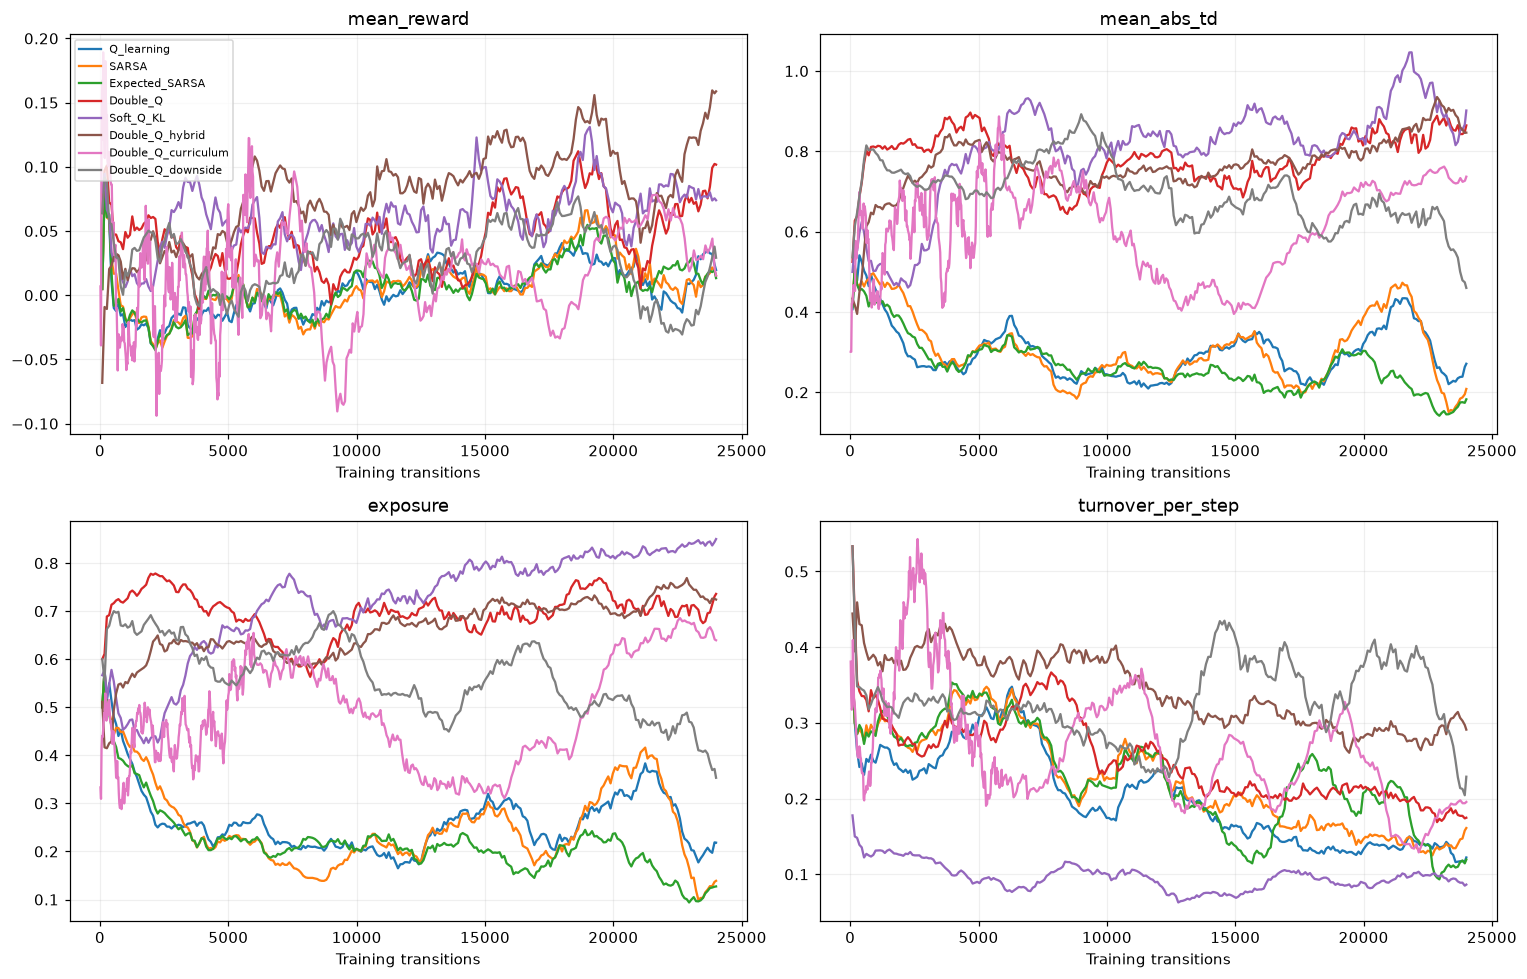

**Output interpretation:** Double_Q_hybrid: median paired score change **+0.1059**, positive for **3/3** seeds. This supports further validation of the variant.

**Output interpretation:** Double_Q_curriculum: median paired score change **+0.1027**, positive for **3/3** seeds. This supports further validation of the variant.

**Output interpretation:** Double_Q_downside: median paired score change **+0.0864**, positive for **2/3** seeds. This supports further validation of the variant.

In [16]:
rl_pairs=[]
for child in ['Double_Q_hybrid','Double_Q_curriculum','Double_Q_downside']:
 a=per_training_seed[per_training_seed.candidate==child].set_index('training_seed')
 b=per_training_seed[per_training_seed.candidate=='Double_Q'].set_index('training_seed')
 d=a.mean_score-b.mean_score
 rl_pairs.append({'child':child,'parent':'Double_Q','median_score_change':d.median(),'positive_seed_pairs':int((d>0).sum())})
display(pd.DataFrame(rl_pairs))
fig,ax=plt.subplots(2,2,figsize=(14,9))
for cfg in RL_CONFIGS:
 z=rl_models[(cfg.name,7)]['logs']
 for axis,col in zip(ax.flat,['mean_reward','mean_abs_td','exposure','turnover_per_step']):
  axis.plot(z.steps,z[col].rolling(20,min_periods=1).mean(),label=cfg.name); axis.set(title=col,xlabel='Training transitions')
ax[0,0].legend(fontsize=7); show()
for row in rl_pairs:
 explain(f'{row["child"]}: median paired score change **{row["median_score_change"]:+.4f}**, positive for **{row["positive_seed_pairs"]}/3** seeds. {"This supports further validation of the variant." if row["median_score_change"]>0 else "The added mechanism did not improve this median validation comparison."}')

## 17. Auxiliary experiment: predicting movement magnitude

The EDA linked volume/range more strongly to return magnitude than direction. As a separate task we compare Ridge and random-forest regression for absolute next-open return, against a training-mean baseline. Fit on training only; validate on the selection block. This auxiliary task is not silently substituted for direction accuracy or used to choose the final trading policy.

In [17]:
# Regression uses imputation/scaling only: a classification ANOVA selector is inappropriate.
def regression_pipeline(estimator):
 return Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler()),('model',estimator)])
MAG_MODELS={'ridge_magnitude':regression_pipeline(Ridge(alpha=10)),'forest_magnitude':regression_pipeline(RandomForestRegressor(n_estimators=160,max_depth=4,min_samples_leaf=25,n_jobs=1,random_state=7))}
MAG_COLS=['volatility5','volatility20','range_pct','relative_volume','vol_ratio','return_lag1']
mag_mean=float(FORWARD.iloc[training].abs().mean()); mag_val=[]
for name,model in MAG_MODELS.items(): model.fit(X.iloc[training][MAG_COLS],FORWARD.iloc[training].abs())
def magnitude_prediction(name,idx):
 return np.full(len(idx),mag_mean) if name=='training_mean' else np.maximum(0,MAG_MODELS[name].predict(X.iloc[idx][MAG_COLS]))
for name in ['training_mean',*MAG_MODELS]:
 pred=magnitude_prediction(name,select); target=FORWARD.iloc[select].abs()
 mag_val.append({'candidate':name,'MAE':mean_absolute_error(target,pred),'RMSE':np.sqrt(mean_squared_error(target,pred)),'R2':r2_score(target,pred)})
mag_val=pd.DataFrame(mag_val).sort_values('MAE'); MAG_WINNER=mag_val.iloc[0].candidate; display(mag_val)
explain(f'The magnitude-task validation winner is **{MAG_WINNER}**. Any improvement here concerns move size, not whether the asset will rise. A useful volatility forecast may inform future exposure sizing, but that would require a separately validated strategy experiment.')

,candidate,MAE,RMSE,R2
2,forest_magnitude,0.00647,0.00855,0.11883
1,ridge_magnitude,0.00658,0.00864,0.09917
0,training_mean,0.00705,0.00913,-0.00664


**Output interpretation:** The magnitude-task validation winner is **forest_magnitude**. Any improvement here concerns move size, not whether the asset will rise. A useful volatility forecast may inform future exposure sizing, but that would require a separately validated strategy experiment.

## 18. Freeze all selections before final-test scoring

In [18]:
ml_val_score=float(strategy_validation.iloc[0].score); rl_val_score=float(rl_rank.iloc[0].median_score)
TRADING_FAMILY='RL' if rl_val_score>ml_val_score else 'ML_or_baseline'
manifest={'dataset_sha256':DATA_HASH,'versions':versions,'bounds':BOUNDS,'feature_columns':ALL,'classification_winner':CLASS_WINNER,'classification_threshold':CLASS_THRESHOLD,'ML_trading_winner':ML_TRADE_WINNER,'RL_winner':RL_WINNER,'RL_representative_seeds':representative,'combined_trading_family':TRADING_FAMILY,'magnitude_winner':MAG_WINNER,'ensemble_members':ensemble_members,'thresholds':thresholds,'ML_rules':ml_rules,'RL_configs':[asdict(c) for c in RL_CONFIGS],'RL_budget':RL_BUDGET,'training_seeds':SEEDS,'validation_execution_seeds':EXECUTION_SEEDS,'fee_per_side':FEE,'test_used_for_current_selection':False,'test_previously_explored':True}
(OUT/'frozen_selections.json').write_text(json.dumps(manifest,indent=2))
np.savez_compressed(OUT/'selected_RL_model.npz',Q=selected_rl['Q'],Q2=selected_rl['Q2'],visits=selected_rl['visits'],vol_edges=vol_edges)
print('Frozen classification:',CLASS_WINNER,'| ML trading:',ML_TRADE_WINNER,'| RL:',RL_WINNER,'| Combined trading family:',TRADING_FAMILY)
explain('The final-test labels have not been used for any fit, threshold choice or winner selection in this study. Previous studies’ exposure to this period remains a research limitation and is recorded in the manifest.')

Frozen classification: extra_trees | ML trading: logistic_top8 | RL: Double_Q_hybrid | Combined trading family: ML_or_baseline


**Output interpretation:** The final-test labels have not been used for any fit, threshold choice or winner selection in this study. Previous studies’ exposure to this period remains a research limitation and is recorded in the manifest.

## 19. Final-test classification: all frozen candidates and baselines

Every supervised candidate is evaluated with default, balanced-tuned and accuracy-tuned thresholds. Results are listed alphabetically rather than selecting a new test winner. Always-up and training-majority predictions establish reference accuracy.

In [19]:
test_class_rows=[]; test_probabilities={}
for name in ML_NAMES:
 p=predict_probability(name,testing); test_probabilities[name]=p
 for rule,threshold in [('default_0.5',.5),('balanced_tuned',thresholds[name]['balanced_accuracy']),('accuracy_tuned',thresholds[name]['accuracy'])]:
  test_class_rows.append({'candidate':name,'rule':rule,'threshold':threshold,**classification_metrics(y.iloc[testing],p,threshold)})
for name,p in [('always_up',np.ones(len(testing))),('training_majority',np.full(len(testing),float(y.iloc[training].mean()>=.5)))]:
 test_class_rows.append({'candidate':name,'rule':'baseline','threshold':.5,**classification_metrics(y.iloc[testing],p)})
test_class=pd.DataFrame(test_class_rows)
display(test_class[(test_class.rule=='balanced_tuned')|(test_class.rule=='baseline')].sort_values('candidate'))
test_class.to_csv(OUT/'test_classification_all_thresholds.csv',index=False)
selected_class=test_class[(test_class.candidate==CLASS_WINNER)&(test_class.rule=='balanced_tuned')].iloc[0]
up_baseline=test_class[test_class.candidate=='always_up'].iloc[0]
explain(f'Frozen winner **{CLASS_WINNER}** achieved **{selected_class.accuracy:.1%} accuracy**, **{selected_class.balanced_accuracy:.1%} balanced accuracy**, and **{selected_class.roc_auc:.3f} ROC-AUC**. Always-up accuracy is **{up_baseline.accuracy:.1%}**, with balanced accuracy **{up_baseline.balanced_accuracy:.1%}**. {"Ordinary accuracy exceeded always-up on this segment." if selected_class.accuracy>up_baseline.accuracy else "Ordinary accuracy did not exceed always-up; do not claim an accuracy gain over that baseline."}')

,candidate,rule,threshold,accuracy,balanced_accuracy,precision_up,recall_up,f1_up,roc_auc,average_precision,brier_loss,log_loss,predicted_up_share
36,always_up,baseline,0.50000,0.56009,0.50000,0.56009,1.00000,0.71802,0.50000,0.56009,0.43991,8.10352,1.00000
16,extra_trees,balanced_tuned,0.52000,0.51288,0.52013,0.58252,0.45977,0.51392,0.52401,0.56608,0.24833,0.68981,0.44206
22,gradient_boost,balanced_tuned,0.53000,0.52146,0.53146,0.59694,0.44828,0.51204,0.52931,0.58510,0.24786,0.68887,0.42060
19,hist_boost,balanced_tuned,0.45000,0.52361,0.49988,0.56000,0.69732,0.62116,0.49119,0.56427,0.26186,0.71815,0.69742
25,knn,balanced_tuned,0.54000,0.50644,0.51700,0.58031,0.42912,0.49339,0.51313,0.56293,0.25553,0.70506,0.41416
4,logistic_compact,balanced_tuned,0.51000,0.53863,0.52009,0.57516,0.67433,0.62081,0.51722,0.57417,0.24806,0.68927,0.65665
7,logistic_full,balanced_tuned,0.52000,0.51931,0.51436,0.57312,0.55556,0.56420,0.53943,0.58779,0.24866,0.69079,0.54292
10,logistic_top8,balanced_tuned,0.53000,0.49571,0.52626,0.61207,0.27203,0.37666,0.54892,0.60568,0.24629,0.68568,0.24893
28,naive_bayes,balanced_tuned,0.55000,0.46996,0.50641,0.57609,0.20307,0.30028,0.47996,0.55986,0.25332,0.70283,0.19742
1,prior_baseline,balanced_tuned,0.50000,0.56009,0.50000,0.56009,1.00000,0.71802,0.50000,0.56009,0.24786,0.68886,1.00000


**Output interpretation:** Frozen winner **extra_trees** achieved **51.3% accuracy**, **52.0% balanced accuracy**, and **0.524 ROC-AUC**. Always-up accuracy is **56.0%**, with balanced accuracy **50.0%**. Ordinary accuracy did not exceed always-up; do not claim an accuracy gain over that baseline.

## 20. Confusion matrix, probability quality and selective coverage

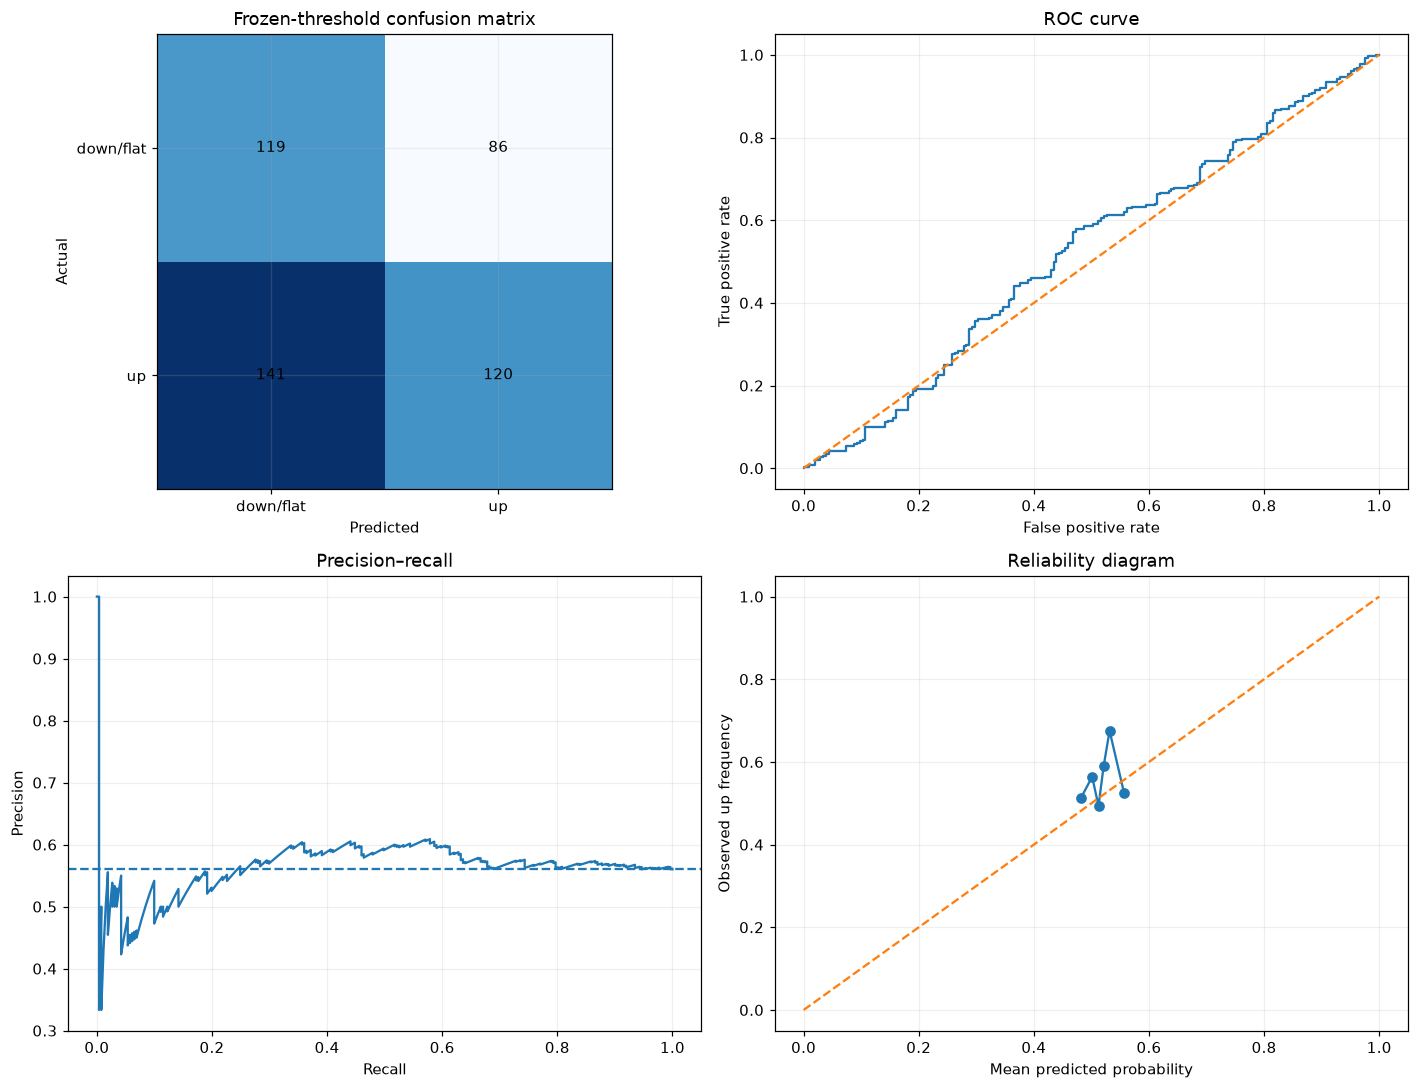

,confidence_cutoff,coverage,days,selective_accuracy
0,0.55000,0.09657,45,0.48889
1,0.60000,0.00644,3,0.33333
2,0.65000,0.00000,0,NaN


,predicted up probability
count,466.00000
mean,0.51744
std,0.02545
min,0.43195
25%,0.50137
50%,0.51710
75%,0.53113
max,0.62196


**Output interpretation:** Inspect the predicted-probability spread and both confusion-matrix rows before attributing a high accuracy to useful learning. Selective scores describe different subsets and are not directly comparable to full-sample scores without coverage.

In [20]:
p=test_probabilities[CLASS_WINNER]; target=y.iloc[testing].to_numpy(); pred=(p>=CLASS_THRESHOLD).astype(int)
cm=confusion_matrix(target,pred,labels=[0,1])
fig,ax=plt.subplots(2,2,figsize=(13,10))
ax[0,0].imshow(cm,cmap='Blues'); ax[0,0].set(xticks=[0,1],yticks=[0,1],xticklabels=['down/flat','up'],yticklabels=['down/flat','up'],xlabel='Predicted',ylabel='Actual',title='Frozen-threshold confusion matrix')
for i in range(2):
 for j in range(2): ax[0,0].text(j,i,str(cm[i,j]),ha='center',va='center')
fpr,tpr,_=roc_curve(target,p); ax[0,1].plot(fpr,tpr); ax[0,1].plot([0,1],[0,1],'--'); ax[0,1].set(title='ROC curve',xlabel='False positive rate',ylabel='True positive rate')
precision,recall,_=precision_recall_curve(target,p); ax[1,0].plot(recall,precision); ax[1,0].axhline(target.mean(),ls='--'); ax[1,0].set(title='Precision–recall',xlabel='Recall',ylabel='Precision')
observed,forecast=calibration_curve(target,p,n_bins=6,strategy='quantile'); ax[1,1].plot(forecast,observed,'o-'); ax[1,1].plot([0,1],[0,1],'--'); ax[1,1].set(title='Reliability diagram',xlabel='Mean predicted probability',ylabel='Observed up frequency'); show()
selective=[]
for confidence in [.55,.60,.65]:
 mask=(p>=confidence)|(p<=1-confidence)
 selective.append({'confidence_cutoff':confidence,'coverage':mask.mean(),'days':int(mask.sum()),'selective_accuracy':accuracy_score(target[mask],(p[mask]>=.5).astype(int)) if mask.any() else np.nan})
display(pd.DataFrame(selective)); display(pd.Series(p).describe().to_frame('predicted up probability'))
explain('Inspect the predicted-probability spread and both confusion-matrix rows before attributing a high accuracy to useful learning. Selective scores describe different subsets and are not directly comparable to full-sample scores without coverage.')

## 21. Final trading evaluation: supervised strategies, RL and baselines

,candidate,net_return,log_growth,max_drawdown,annualized_vol,sharpe_zero_rf,exposure,turnover,score
1,buy_hold,0.52743,0.42359,-0.15974,0.21203,1.18687,1.00000,2,0.34372
0,cash,0.00000,0.00000,0.00000,0.00000,NaN,0.00000,0,0.00000
7,extra_trees,0.53680,0.42970,-0.15974,0.20315,1.24594,0.90987,8,0.34983
9,gradient_boost,0.43298,0.35976,-0.13646,0.18284,1.15581,0.72961,26,0.29153
8,hist_boost,0.18386,0.16878,-0.17318,0.18446,0.58704,0.69742,182,0.08219
10,knn,0.16667,0.15415,-0.06172,0.10873,0.82064,0.33047,160,0.12329
3,logistic_compact,0.52292,0.42063,-0.15974,0.21132,1.18258,0.98712,2,0.34076
4,logistic_full,0.00946,0.00942,-0.11985,0.08784,0.10206,0.25322,120,-0.05051
5,logistic_top8,0.69968,0.53044,-0.14814,0.19075,1.59997,0.86910,12,0.45637
11,naive_bayes,0.31261,0.27202,-0.21672,0.17083,0.94678,0.80258,10,0.16366


,mean_return,min_return,max_return,mean_drawdown,mean_score,mean_turnover,action_direction_agreement
candidate,,,,,,,
Double_Q,0.42255,0.42255,0.42255,-0.13646,0.28422,44.00000,0.52575
Double_Q_curriculum,0.25804,0.25804,0.25804,-0.14814,0.15548,72.00000,0.51931
Double_Q_downside,0.00937,0.00937,0.00937,-0.08953,-0.03544,26.00000,0.45923
Double_Q_hybrid,0.36272,0.36272,0.36272,-0.12965,0.24466,108.00000,0.55150
Expected_SARSA,0.02795,0.02795,0.02795,-0.00100,0.02707,2.00000,0.44206
Q_learning,0.13467,0.13467,0.13467,-0.03377,0.10945,10.00000,0.46352
SARSA,0.08759,0.08759,0.08759,-0.05356,0.05718,44.00000,0.46567
Soft_Q_KL,0.29855,-0.07070,0.53215,-0.19204,0.14911,44.00000,0.54163


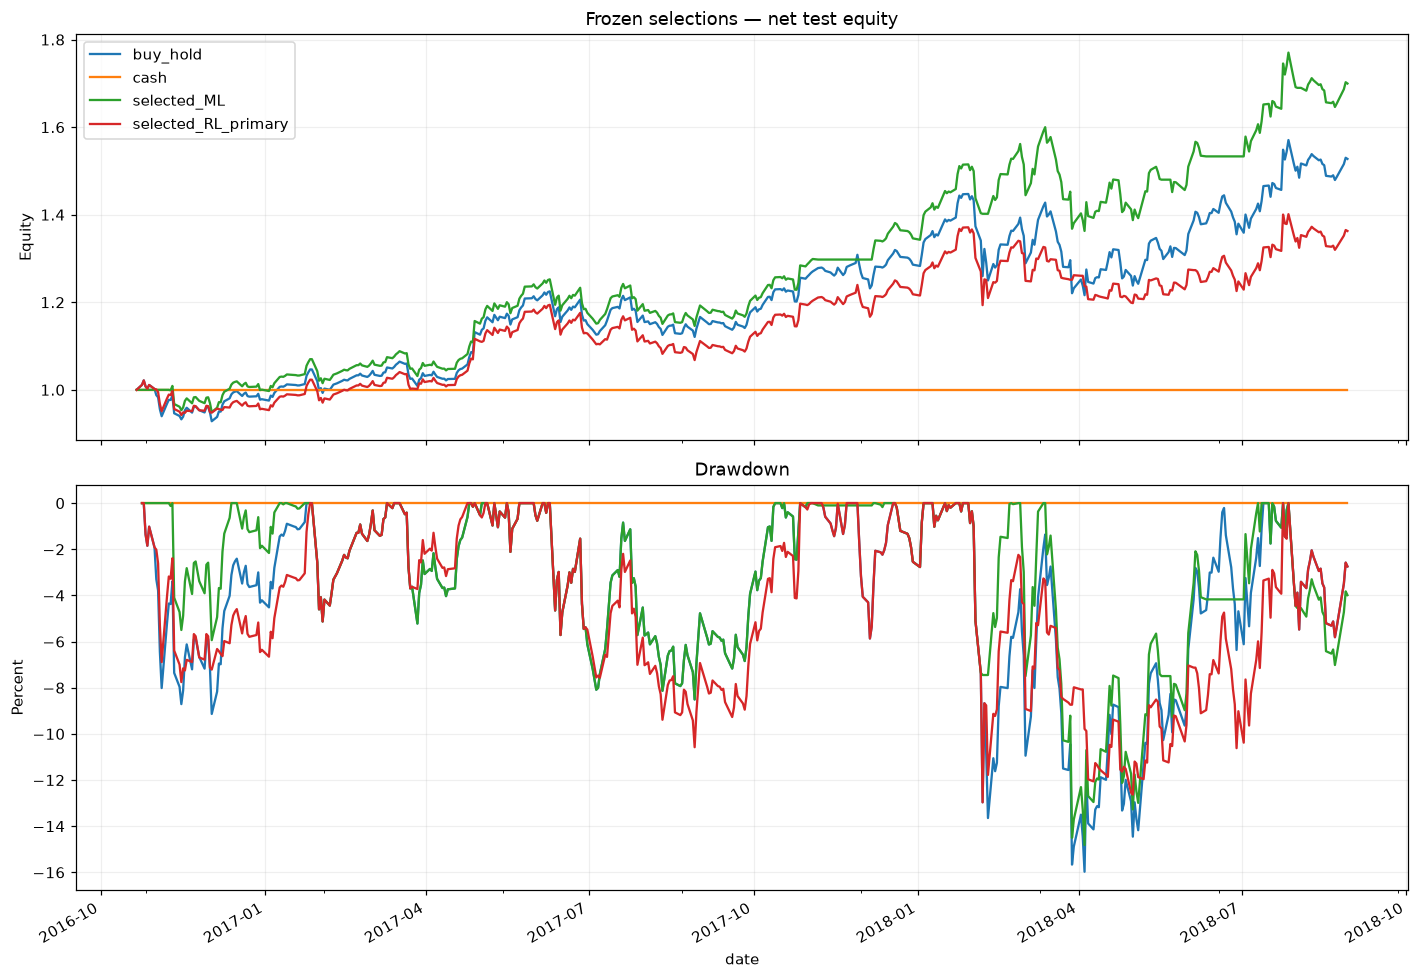

**Output interpretation:** Buy-and-hold returned **52.74%**. Frozen ML/baseline selection **logistic_top8** returned **69.97%**. Frozen RL selection **Double_Q_hybrid** averaged **36.27%** across five execution paths. These outcomes are separate from prediction accuracy; no test winner is substituted for the frozen selections.

In [21]:
def ml_actions(name,idx):
 if name=='cash': return np.zeros(len(idx),dtype=int)
 if name=='buy_hold': return np.ones(len(idx),dtype=int)
 return actions_from_probability(predict_probability(name,idx),idx,ml_rules[name],thresholds[name]['balanced_accuracy'])
ml_test_rows=[]; ml_paths={}
for name in ['cash','buy_hold',*ML_NAMES]:
 path=path_from_actions(testing,ml_actions(name,testing)); ml_paths[name]=path
 ml_test_rows.append({'candidate':name,**trading_metrics(path)})
ml_test=pd.DataFrame(ml_test_rows); display(ml_test.sort_values('candidate')); ml_test.to_csv(OUT/'test_supervised_trading.csv',index=False)
rl_test_rows=[]; rl_primary_paths={}
for cfg in RL_CONFIGS:
 model=rl_models[(cfg.name,representative[cfg.name])]
 for exec_seed in EXECUTION_SEEDS:
  path=evaluate_rl(model,testing,exec_seed)
  rl_test_rows.append({'candidate':cfg.name,'training_seed':representative[cfg.name],'execution_seed':exec_seed,'action_direction_agreement':accuracy_score(y.iloc[testing],path.action),'unseen_states':path.attrs['unseen_states'],**trading_metrics(path)})
  if exec_seed==EXECUTION_SEEDS[0]: rl_primary_paths[cfg.name]=path
rl_test=pd.DataFrame(rl_test_rows)
rl_test_summary=rl_test.groupby('candidate').agg(mean_return=('net_return','mean'),min_return=('net_return','min'),max_return=('net_return','max'),mean_drawdown=('max_drawdown','mean'),mean_score=('score','mean'),mean_turnover=('turnover','mean'),action_direction_agreement=('action_direction_agreement','mean'))
display(rl_test_summary); rl_test.to_csv(OUT/'test_rl_execution_runs.csv',index=False)
fig,ax=plt.subplots(2,1,figsize=(13,9),sharex=True)
for name,path in {'buy_hold':ml_paths['buy_hold'],'cash':ml_paths['cash'],'selected_ML':ml_paths[ML_TRADE_WINNER],'selected_RL_primary':rl_primary_paths[RL_WINNER]}.items():
 pd.concat([pd.Series([1.],index=[df.index[testing[0]]]),path.equity]).plot(ax=ax[0],label=name)
 (path.drawdown*100).plot(ax=ax[1],label=name)
 path.to_csv(OUT/f'path_{name}.csv')
ax[0].legend(); ax[0].set(title='Frozen selections — net test equity',ylabel='Equity'); ax[1].set(title='Drawdown',ylabel='Percent'); show()
BH_RETURN=float(ml_test.set_index('candidate').loc['buy_hold','net_return'])
explain(f'Buy-and-hold returned **{BH_RETURN:.2%}**. Frozen ML/baseline selection **{ML_TRADE_WINNER}** returned **{ml_test.set_index("candidate").loc[ML_TRADE_WINNER,"net_return"]:.2%}**. Frozen RL selection **{RL_WINNER}** averaged **{rl_test_summary.loc[RL_WINNER,"mean_return"]:.2%}** across five execution paths. These outcomes are separate from prediction accuracy; no test winner is substituted for the frozen selections.')

## 22. Execution randomness and cost stress tests

,net_return,max_drawdown,score,turnover
count,20.00000,20.00000,20.00000,20.00000
mean,0.36272,-0.12965,0.24466,108.00000
std,0.00000,0.00000,0.00000,0.00000
min,0.36272,-0.12965,0.24466,108.00000
25%,0.36272,-0.12965,0.24466,108.00000
50%,0.36272,-0.12965,0.24466,108.00000
75%,0.36272,-0.12965,0.24466,108.00000
max,0.36272,-0.12965,0.24466,108.00000


strategy,buy_hold,selected_ML,selected_RL
fee_bps_per_side,,,
0,0.53049,0.72021,0.51822
5,0.52896,0.70992,0.43839
10,0.52743,0.69968,0.36272
25,0.52284,0.66931,0.15858
50,0.51522,0.61979,-0.11646


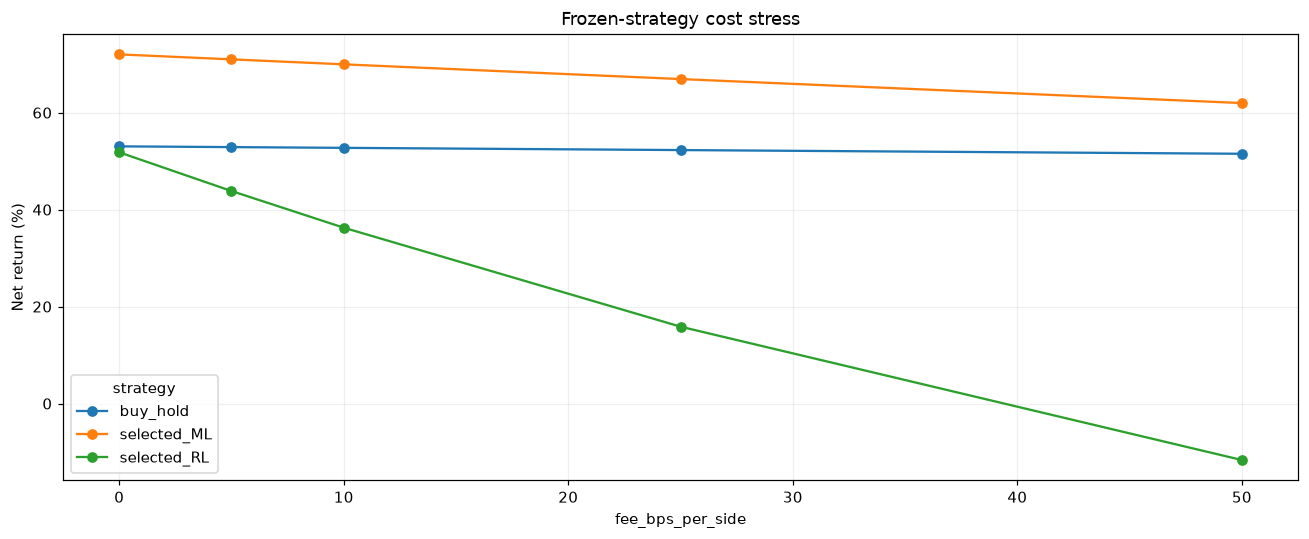

**Output interpretation:** The selected RL policy beat buy-and-hold in **0/20** additional execution paths; median return **36.27%**. Deterministic repeats are one market experiment repeated identically, not 20 independent confirmations. Sensitivity to costs can erase an apparent gross edge.

In [22]:
robust_rl=pd.DataFrame([{'execution_seed':seed,**trading_metrics(evaluate_rl(selected_rl,testing,seed))} for seed in range(1000,1020)])
display(robust_rl[['net_return','max_drawdown','score','turnover']].describe())
robust_rl.to_csv(OUT/'selected_rl_execution_robustness.csv',index=False)
stress=[]
for bps in [0,5,10,25,50]:
 for name in ['buy_hold','selected_ML','selected_RL']:
  if name=='selected_RL':
   metrics_list=[trading_metrics(evaluate_rl(selected_rl,testing,seed,bps/10000)) for seed in EXECUTION_SEEDS]
   result={k:float(np.nanmean([m[k] for m in metrics_list])) if any(np.isfinite(m[k]) for m in metrics_list) else np.nan for k in metrics_list[0]}
  else: result=trading_metrics(path_from_actions(testing,ml_actions('buy_hold' if name=='buy_hold' else ML_TRADE_WINNER,testing),bps/10000))
  stress.append({'fee_bps_per_side':bps,'strategy':name,**result})
stress=pd.DataFrame(stress); display(stress.pivot(index='fee_bps_per_side',columns='strategy',values='net_return'))
(stress.pivot(index='fee_bps_per_side',columns='strategy',values='net_return')*100).plot(marker='o',title='Frozen-strategy cost stress',ylabel='Net return (%)'); show()
stress.to_csv(OUT/'cost_stress.csv',index=False)
explain(f'The selected RL policy beat buy-and-hold in **{int((robust_rl.net_return>BH_RETURN).sum())}/20** additional execution paths; median return **{robust_rl.net_return.median():.2%}**. Deterministic repeats are one market experiment repeated identically, not 20 independent confirmations. Sensitivity to costs can erase an apparent gross edge.')

## 23. Classification uncertainty: paired block bootstrap

In [23]:
rng=np.random.default_rng(802); target=y.iloc[testing].to_numpy(); p=test_probabilities[CLASS_WINNER]; pred=(p>=CLASS_THRESHOLD).astype(int); base=np.ones_like(target)
bootstrap=[]; trading_bootstrap=[]
trade_differences={'selected_ML':(ml_paths[ML_TRADE_WINNER].log_return-ml_paths['buy_hold'].log_return).to_numpy(),'selected_RL_primary':(rl_primary_paths[RL_WINNER].log_return-ml_paths['buy_hold'].log_return).to_numpy()}
for block in [5,10,21]:
 differences=[]; trade_means={name:[] for name in trade_differences}
 for _ in range(1500):
  starts=rng.integers(0,len(target),size=int(np.ceil(len(target)/block)))
  take=((starts[:,None]+np.arange(block))%len(target)).ravel()[:len(target)]
  for name,difference in trade_differences.items(): trade_means[name].append(difference[take].mean())
  yt=target[take]; pt=pred[take]; bt=base[take]
  # Both classes occur in these long blocks; keep an explicit guard for reuse on smaller datasets.
  if len(np.unique(yt))<2: continue
  differences.append([accuracy_score(yt,pt)-accuracy_score(yt,bt),balanced_accuracy_score(yt,pt)-balanced_accuracy_score(yt,bt)])
 values=np.asarray(differences)
 for j,metric in enumerate(['accuracy_difference','balanced_accuracy_difference']):
  low,high=np.quantile(values[:,j],[.025,.975])
  bootstrap.append({'block_sessions':block,'metric':metric,'CI_low':low,'CI_high':high,'replicates':len(values)})
 for name,means in trade_means.items():
  low,high=np.quantile(means,[.025,.975])
  trading_bootstrap.append({'block_sessions':block,'strategy':name,'mean_daily_log_outperformance':trade_differences[name].mean(),'CI_low':low,'CI_high':high})
bootstrap=pd.DataFrame(bootstrap); display(bootstrap); bootstrap.to_csv(OUT/'classification_paired_bootstrap.csv',index=False)
trading_bootstrap=pd.DataFrame(trading_bootstrap); display(trading_bootstrap); trading_bootstrap.to_csv(OUT/'trading_paired_bootstrap.csv',index=False)
explain('An interval spanning zero does not establish improvement over always-up for that metric. Balanced accuracy may improve while ordinary accuracy falls, because it rewards correct down-day detection as well as up-day detection. Both results must be stated.')

,block_sessions,metric,CI_low,CI_high,replicates
0,5,accuracy_difference,-0.11588,0.02146,1500
1,5,balanced_accuracy_difference,-0.02043,0.06399,1500
2,10,accuracy_difference,-0.11588,0.01502,1500
3,10,balanced_accuracy_difference,-0.02600,0.06025,1500
4,21,accuracy_difference,-0.10944,0.01931,1500
5,21,balanced_accuracy_difference,-0.01827,0.05766,1500


,block_sessions,strategy,mean_daily_log_outperformance,CI_low,CI_high
0,5,selected_ML,0.00023,-0.00019,0.00070
1,5,selected_RL_primary,-0.00024,-0.00078,0.00024
2,10,selected_ML,0.00023,-0.00014,0.00068
3,10,selected_RL_primary,-0.00024,-0.00074,0.00023
4,21,selected_ML,0.00023,-0.00011,0.00061
5,21,selected_RL_primary,-0.00024,-0.00059,0.00008


**Output interpretation:** An interval spanning zero does not establish improvement over always-up for that metric. Balanced accuracy may improve while ordinary accuracy falls, because it rewards correct down-day detection as well as up-day detection. Both results must be stated.

## 24. Error analysis by regime and calendar period

In [24]:
error=pd.DataFrame({'actual':y.iloc[testing].to_numpy(),'probability':test_probabilities[CLASS_WINNER],'prediction':(test_probabilities[CLASS_WINNER]>=CLASS_THRESHOLD).astype(int),'forward_return':FORWARD.iloc[testing].to_numpy(),'vol_regime':VOL_BIN[testing]},index=df.index[testing])
error['correct']=error.actual.eq(error.prediction); error['year']=error.index.year
regime_rows=[]
for key,group in error.groupby('vol_regime'):
 regime_rows.append({'volatility_regime':key,'n':len(group),'up_share':group.actual.mean(),'accuracy':group.correct.mean(),'balanced_accuracy':balanced_accuracy_score(group.actual,group.prediction) if group.actual.nunique()==2 else np.nan,'mean_abs_move':group.forward_return.abs().mean()})
display(pd.DataFrame(regime_rows)); display(error.groupby('year').agg(n=('correct','size'),accuracy=('correct','mean'),up_share=('actual','mean')))
display(error[~error.correct].assign(abs_move=lambda z:z.forward_return.abs()).nlargest(10,'abs_move'))
error.to_csv(OUT/'test_daily_prediction_errors.csv')
explain('Differences across volatility states or years are retrospective diagnostics, not permission to add a test-fitted regime filter. Investigate the largest errors and class balance before changing the model on genuinely new validation data.')

,volatility_regime,n,up_share,accuracy,balanced_accuracy,mean_abs_move
0,0,255,0.56471,0.50588,0.52224,0.00755
1,1,113,0.57522,0.47788,0.48349,0.00976
2,2,98,0.53061,0.57143,0.56605,0.01423


,n,accuracy,up_share
year,,,
2016,49,0.57143,0.55102
2017,251,0.49402,0.58964
2018,166,0.52410,0.51807


,actual,probability,prediction,forward_return,vol_regime,correct,year,abs_move
Date,,,,,,,,
2018-03-27,0,0.59320,1,-0.05827,2,False,2018,0.05827
2018-02-06,1,0.50184,0,0.04931,2,False,2018,0.04931
2018-03-01,0,0.54546,1,-0.04647,2,False,2018,0.04647
2017-04-27,1,0.50380,0,0.04382,0,False,2017,0.04382
2016-11-04,1,0.50908,0,0.03066,0,False,2016,0.03066
2018-07-02,1,0.51612,0,0.03055,0,False,2018,0.03055
2018-05-09,1,0.50514,0,0.02904,2,False,2018,0.02904
2017-06-26,0,0.52139,1,-0.02869,0,False,2017,0.02869
2018-05-31,1,0.51894,0,0.02853,1,False,2018,0.02853


**Output interpretation:** Differences across volatility states or years are retrospective diagnostics, not permission to add a test-fitted regime filter. Investigate the largest errors and class balance before changing the model on genuinely new validation data.

## 25. Validation permutation importance and selected-feature audit

In [25]:
individual_name=cv_summary[cv_summary.family!='dummy'].iloc[0].candidate
entry=fitted[individual_name]
importance=permutation_importance(entry['estimator'],X.iloc[select][entry['cols']],y.iloc[select],scoring='balanced_accuracy',n_repeats=8,random_state=7,n_jobs=1)
importance_table=pd.DataFrame({'feature':entry['cols'],'mean_score_drop':importance.importances_mean,'repeat_std':importance.importances_std}).sort_values('mean_score_drop',ascending=False)
display(importance_table)
mask=fitted['logistic_top8']['estimator'].named_steps['select'].get_support()
print('Training-selected top-8 features:',np.array(ALL)[mask].tolist())
importance_table.to_csv(OUT/'validation_permutation_importance.csv',index=False)
explain(f'Importance describes **{individual_name}**, not necessarily the final selected ensemble or RL policy. Negative importance means this permutation increased the observed score; it may reflect noise or a harmful/redundant feature. No feature is removed in response to these postselection diagnostics.')

,feature,mean_score_drop,repeat_std
18,relative_volume,0.01979,0.01111
6,momentum20,0.01303,0.01020
3,return_lag5,0.01218,0.02393
14,bb_width,0.00228,0.00702
10,rsi,0.00000,0.00000
11,volatility5,0.00000,0.00000
19,log_volume_change,0.00000,0.00000
16,intraday,0.00000,0.00000
13,vol_ratio,0.00000,0.00000
12,volatility20,0.00000,0.00000


Training-selected top-8 features: ['return_lag1', 'return_lag5', 'momentum20', 'price_sma20', 'macd_pct', 'rsi', 'bb_width', 'overnight']


**Output interpretation:** Importance describes **gradient_boost**, not necessarily the final selected ensemble or RL policy. Negative importance means this permutation increased the observed score; it may reflect noise or a harmful/redundant feature. No feature is removed in response to these postselection diagnostics.

## 26. Auxiliary magnitude test and feature-ablation conclusions

In [26]:
mag_test=[]
for name in ['training_mean',*MAG_MODELS]:
 pred_mag=magnitude_prediction(name,testing); target_mag=FORWARD.iloc[testing].abs()
 mag_test.append({'candidate':name,'selected_on_validation':name==MAG_WINNER,'MAE':mean_absolute_error(target_mag,pred_mag),'RMSE':np.sqrt(mean_squared_error(target_mag,pred_mag)),'R2':r2_score(target_mag,pred_mag)})
mag_test=pd.DataFrame(mag_test); display(mag_test); mag_test.to_csv(OUT/'test_magnitude_regression.csv',index=False)
feature_compare=validation_ml[(validation_ml.candidate.isin(['logistic_compact','logistic_full','logistic_top8']))&(validation_ml.rule=='balanced_tuned')]
display(feature_compare[['candidate','balanced_accuracy','accuracy','roc_auc','brier_loss']])
selected_mag=mag_test[mag_test.selected_on_validation].iloc[0]; base_mag=mag_test[mag_test.candidate=='training_mean'].iloc[0]
explain(f'The frozen magnitude model **{MAG_WINNER}** has test MAE **{selected_mag.MAE:.5f}**, versus **{base_mag.MAE:.5f}** for the training-mean baseline. {"It reduced magnitude-prediction MAE." if selected_mag.MAE<base_mag.MAE else "It did not improve magnitude-prediction MAE."} This does not change the directional-accuracy verdict.')

,candidate,selected_on_validation,MAE,RMSE,R2
0,training_mean,False,0.00700,0.00949,-0.01207
1,ridge_magnitude,False,0.00670,0.00916,0.05656
2,forest_magnitude,True,0.00660,0.00908,0.07371


,candidate,balanced_accuracy,accuracy,roc_auc,brier_loss
4,logistic_compact,0.49477,0.51073,0.50156,0.24897
7,logistic_full,0.54113,0.53648,0.54421,0.24945
10,logistic_top8,0.53538,0.51502,0.54895,0.24811


**Output interpretation:** The frozen magnitude model **forest_magnitude** has test MAE **0.00660**, versus **0.00700** for the training-mean baseline. It reduced magnitude-prediction MAE. This does not change the directional-accuracy verdict.

## 27. Final evidence-based conclusions

In [27]:
accuracy_gain=selected_class.accuracy-up_baseline.accuracy
balanced_gain=selected_class.balanced_accuracy-up_baseline.balanced_accuracy
ml_return=float(ml_test.set_index('candidate').loc[ML_TRADE_WINNER,'net_return'])
rl_return=float(rl_test_summary.loc[RL_WINNER,'mean_return'])
verdict=pd.DataFrame([
 {'question':'Did ordinary directional accuracy beat always-up?','selected_result':selected_class.accuracy,'baseline_result':up_baseline.accuracy,'improved':bool(accuracy_gain>0)},
 {'question':'Did balanced accuracy beat always-up?','selected_result':selected_class.balanced_accuracy,'baseline_result':up_baseline.balanced_accuracy,'improved':bool(balanced_gain>0)},
 {'question':'Did selected ML/baseline strategy beat buy-and-hold?','selected_result':ml_return,'baseline_result':BH_RETURN,'improved':bool(ml_return>BH_RETURN)},
 {'question':'Did selected RL mean return beat buy-and-hold?','selected_result':rl_return,'baseline_result':BH_RETURN,'improved':bool(rl_return>BH_RETURN)}
]); display(verdict); verdict.to_csv(OUT/'conclusions.csv',index=False)
explain(f'**Prediction:** {CLASS_WINNER} achieved **{selected_class.accuracy:.1%} accuracy** and **{selected_class.balanced_accuracy:.1%} balanced accuracy**. Relative to always-up, the changes are **{accuracy_gain*100:+.2f}** and **{balanced_gain*100:+.2f} percentage points** respectively. The two metrics can disagree; report both.')
explain(f'**Trading:** supervised/baseline selection {ML_TRADE_WINNER} returned **{ml_return:.2%}**; RL selection {RL_WINNER} averaged **{rl_return:.2%}**; buy-and-hold returned **{BH_RETURN:.2%}**. Direction accuracy alone cannot explain those differences: turnover, missed exposure and move magnitudes also matter.')
explain('**Strength of evidence:** use the paired intervals, chronological fold spread, seed variation, fee sensitivity and regime errors together. The final historical period has been reused across studies, so even a positive result is exploratory. A credible next step is to freeze this protocol and evaluate on new dates/assets or run a genuinely nested walk-forward study; do not tune repeatedly against this final segment.')
ml_intervals=trading_bootstrap[trading_bootstrap.strategy=='selected_ML']
explain(f'**Trading uncertainty:** the selected ML strategy’s relative-return intervals include zero for **{int(((ml_intervals.CI_low<=0)&(ml_intervals.CI_high>=0)).sum())}/3** block lengths. A positive realized return difference alone is not proof of a persistent edge. The classification intervals likewise determine whether the modest balanced-accuracy gain is distinguishable from sampling variability.')

,question,selected_result,baseline_result,improved
0,Did ordinary directional accuracy beat always-up?,0.51288,0.56009,False
1,Did balanced accuracy beat always-up?,0.52013,0.50000,True
2,Did selected ML/baseline strategy beat buy-and...,0.69968,0.52743,True
3,Did selected RL mean return beat buy-and-hold?,0.36272,0.52743,False


**Output interpretation:** **Prediction:** extra_trees achieved **51.3% accuracy** and **52.0% balanced accuracy**. Relative to always-up, the changes are **-4.72** and **+2.01 percentage points** respectively. The two metrics can disagree; report both.

**Output interpretation:** **Trading:** supervised/baseline selection logistic_top8 returned **69.97%**; RL selection Double_Q_hybrid averaged **36.27%**; buy-and-hold returned **52.74%**. Direction accuracy alone cannot explain those differences: turnover, missed exposure and move magnitudes also matter.

**Output interpretation:** **Strength of evidence:** use the paired intervals, chronological fold spread, seed variation, fee sensitivity and regime errors together. The final historical period has been reused across studies, so even a positive result is exploratory. A credible next step is to freeze this protocol and evaluate on new dates/assets or run a genuinely nested walk-forward study; do not tune repeatedly against this final segment.

**Output interpretation:** **Trading uncertainty:** the selected ML strategy’s relative-return intervals include zero for **3/3** block lengths. A positive realized return difference alone is not proof of a persistent edge. The classification intervals likewise determine whether the modest balanced-accuracy gain is distinguishable from sampling variability.

## 28. Reproducibility and final integrity checks

Artifacts include fold-level scores, all tuned thresholds, all rule-search results, validation selections, final prediction errors, RL seed results, cost sensitivity, figures and conclusions. The selected RL numeric arrays and manifest are sufficient to inspect its learned table; supervised estimators are reproducibly refitted by rerunning this file with the recorded versions.

Method references: [scikit-learn TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html), [balanced accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html), [model evaluation metrics](https://scikit-learn.org/stable/modules/model_evaluation.html), and the RL references in Section 13. These define methods; no external performance claim replaces the results computed here.

In [28]:
assert len(rl_models)==24
for model in rl_models.values():
 assert model['visits'].sum()==RL_BUDGET
 assert model['logs'].steps.iloc[-1]==RL_BUDGET
assert len(test_class)==len(ML_NAMES)*3+2
assert np.isfinite(test_class[['accuracy','balanced_accuracy','brier_loss','log_loss']]).all().all()
assert all(len(path)==len(testing) for path in ml_paths.values())
assert all(np.isfinite(path.equity).all() and (path.equity>0).all() for path in ml_paths.values())
assert len(testing)==466
(OUT/'requirements_versions.txt').write_text('\n'.join(f'{p}=={v}' for p,v in versions.items())+'\n')
pd.DataFrame(threshold_rows).to_csv(OUT/'validation_tuned_thresholds.csv',index=False)
print('PASS: 24 RL runs with identical 24,000-transition budgets, all classifiers scored, 466 common test intervals, finite metrics and positive wealth.')
print('Artifacts:',OUT.resolve())

PASS: 24 RL runs with identical 24,000-transition budgets, all classifiers scored, 466 common test intervals, finite metrics and positive wealth.
Artifacts: /Users/rashiojha/Downloads/untitled folder 8/ml_rl_outputs
